# Compute Level vs. Accuracy, Latency and Reasoning Efficiency

**Goal.** Quantify how the *compute level* given to an LLM relates to (i) accuracy, (ii) elapsed time and (iii) token efficiency, using repeated samples of benchmark questions.

**How to use.** Set `DATA_PATH` and `SAVE_DIR` (the folder where **every figure is saved** as a PNG) in the configuration cell below and run all cells. Every table and figure is computed from your file; nothing in this notebook is hard-coded.

**Storyline**

| # | Section | Question answered |
|---|---------|-------------------|
| 0 | Methodology | How are numbers aggregated and how is uncertainty measured? |
| 1 | Data understanding & validation | Is the data complete, consistent and balanced across compute levels? |
| 2 | Baseline | What does naive pooled accuracy look like, and why is it not enough? |
| 3 | Per-benchmark behaviour | Does each benchmark improve with compute? |
| 4 | Task types | Do open-ended, MCQ and True/False tasks scale differently? |
| 5 | Normalised aggregate curve | What is the overall curve once benchmark size and coverage are neutralised? |
| 6 | Diminishing returns | Where do additional compute levels stop paying off? |
| 7 | Difficulty effects | Does compute help easy, medium or hard questions more? |
| 8 | Latency | How does elapsed time grow with compute? |
| 9 | Token efficiency | What does each extra point of accuracy cost? |
| 10 | Repeated samples | How consistent are samples, and what does pass@k add? |
| 11 | Truncation & response format | How much is lost to token limits and format failures? |
| 12 | Synthesis | What can (and cannot) be concluded? |

In [85]:
# ============================ CONFIGURATION ============================
DATA_PATH = "../../data/raw/qwen3-0.6B/qwen3-.06B_raw_results.csv"   # <-- SET THIS: .csv, .tsv, .parquet, .jsonl or .json
SAVE_DIR = "../../results/r1-llama8b_raw_results/compute_level_analysis/Figures"   # <-- SET THIS: folder where ALL figures are saved as PNG (created if missing)

# ---- Optional settings (defaults are sensible) ----
COMPUTE_ORDER = None          # e.g. ["low", "medium", "high"]; None = infer the order automatically
TIER_ORDER = None             # e.g. ["easy", "medium", "hard"]; None = infer automatically
TASK_TYPE_SOURCE = "benchmark"     # "column" = use the task_type column, "inferred" = infer from `gold`, "auto" = column if informative
TASK_TYPE_MAP = {
    "MMLU-Redux": "MCQ",
    "MMLU-Pro": "MCQ",
    "GPQA-Diamond": "MCQ",
    "GSM8K": "Open-ended",
    "MATH-full": "Open-ended",
    "AIME2025": "Open-ended",
    "LiveCodeBench-v6": "Open-ended",
    "IFEval": "Open-ended",
    "BFCL-v3-simple": "Open-ended",
}       
N_BOOT = 2000                 # bootstrap replicates (use ~200 for a quick draft)
CI_LEVEL = 0.95               # confidence level of all intervals
SEED = 42                     # random seed (bootstrap, plotting subsamples)
MISSING_CORRECT = "drop"      # rows whose is_correct cannot be read: "drop" (counted and reported) or "incorrect"
DROP_DUPLICATES = False       # True = keep only the first row of repeated (benchmark, question, level, sample) keys
MIN_QUESTIONS_PER_CELL = 20   # cells (e.g. benchmark x level) with fewer questions are flagged as low-n in tables

In [86]:
# ----------------------------- Imports & style -----------------------------
import math
import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)   # nanmean of empty slices is expected for missing cells
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 9, "axes.prop_cycle": plt.cycler(color=[
        "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#000000", "#999999"]),
})
# Okabe-Ito colour-blind-safe palette (yellow omitted: poor contrast on white)
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#000000", "#999999"]
Z = NormalDist().inv_cdf(0.5 + CI_LEVEL / 2)


def md(text):
    """Render Markdown produced by code (used for data-driven 'Observed' notes)."""
    display(Markdown(text))


if SAVE_DIR in (None, "", "PATH/TO/SAVE/FIGURES"):
    raise ValueError("Set SAVE_DIR in the configuration cell: the folder where every figure will be saved.")
SAVE_PATH = Path(SAVE_DIR).expanduser()
SAVE_PATH.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {SAVE_PATH.resolve()}")


def finish(fig, name):
    """Tidy, save to SAVE_DIR (always) and show a figure."""
    fig.tight_layout()
    out = SAVE_PATH / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {out}")
    plt.show()

Figures will be saved to: C:\Users\afath\Desktop\Orange Lab\test-time-compute-allocation\src\results\r1-llama8b_raw_results\compute_level_analysis\Figures


## 0. Methodology (read this first)

**Unit of analysis.** The independent unit is the **question**, not the row. Each question is answered several times (`sample_index`) at each compute level, and those samples are correlated. All uncertainty is therefore computed by **resampling questions** (a *cluster bootstrap*, percentile intervals) so that repeated samples do not create false precision. Where a pooled proportion is reported, its interval uses question-clustered standard errors; the naive binomial interval is shown once for comparison.

**Aggregation (the Simpson's-paradox guard).** Pooled accuracy (every row weighted equally) is dominated by the largest benchmarks and is distorted when the benchmark mix differs between compute levels. We therefore use:

* **Macro-average:** accuracy is first averaged *within* each benchmark (over questions, then over levels), and benchmarks are then averaged with **equal weight**.
* **Full-coverage benchmarks only** for cross-level comparisons: a benchmark enters a macro-average only if it is observed at *every* compute level, so the set of benchmarks never changes along the curve.
* **Same-question comparison (primary estimate):** within those benchmarks, only questions observed at *every* compute level are used, so level-to-level differences are *paired* differences on identical questions.
* Pooled and "all-available" macro versions are shown next to the primary estimate, together with a coverage/composition diagnostic, so differences can be audited rather than assumed.

The same rule is used for task types (macro over benchmark x task-type cells within a type) and for difficulty tiers (macro over benchmark x tier cells within a tier).

**Interpretation limits.** Benchmarks are treated as a *fixed* set: intervals describe sampling uncertainty over questions, not over the population of possible benchmarks. Compute level is observed, not randomised by us, so statements are about association in this dataset unless the experiment itself was controlled. Nothing is silently dropped: every exclusion is counted and printed.

## 1. Data understanding and validation

Before any modelling we check that the file has the expected structure, that values are readable, and — most importantly for this study — **how complete the benchmark x compute-level design is**. Incomplete coverage is the main source of misleading aggregates, so it is measured here and used throughout.

In [87]:
# ------------------------------ Load -------------------------------------
path = Path(DATA_PATH).expanduser()
if not path.exists():
    raise FileNotFoundError(f"Dataset not found at '{path}'. Set DATA_PATH in the first cell.")

readers = {
    ".csv": pd.read_csv, ".tsv": lambda p: pd.read_csv(p, sep="\t"),
}
if path.suffix.lower() not in readers:
    raise ValueError(f"Unsupported file type '{path.suffix}'. Supported: {sorted(readers)}")
raw = readers[path.suffix.lower()](path)
print(f"Loaded {len(raw):,} rows x {raw.shape[1]} columns from '{path.name}'")

EXPECTED = ["question_id", "benchmark", "difficulty_tier", "task_type", "compute_level", "sample_index",
            "raw_model_output", "thinking_text", "gold", "is_correct", "tokens_used", "thinking_tokens",
            "output_tokens", "hit_response_marker", "latency_s", "was_truncated", "hit_marker_empty_output"]
REQUIRED = ["question_id", "benchmark", "compute_level", "is_correct"]   # the analysis cannot run without these

missing_required = [c for c in REQUIRED if c not in raw.columns]
if missing_required:
    raise KeyError(f"Required columns missing: {missing_required}. Found: {list(raw.columns)}")
missing_optional = [c for c in EXPECTED if c not in raw.columns]
if missing_optional:
    print("Optional columns absent (related analyses are simplified or skipped):", missing_optional)
extra = [c for c in raw.columns if c not in EXPECTED]
if extra:
    print("Additional columns present (ignored):", extra)

Loaded 29,050 rows x 17 columns from 'qwen3-.06B_raw_results.csv'


In [88]:
# --------------------------- Clean & standardise --------------------------
def to_float01(s):
    """Convert booleans / 'True'/'False' / 0/1 / yes/no to 1.0/0.0; unreadable values become NaN."""
    if s.dtype == bool:
        return s.astype(float)
    m = {"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0, "1.0": 1.0, "0.0": 0.0, "yes": 1.0, "no": 0.0, "t": 1.0, "f": 0.0}
    return s.astype(str).str.strip().str.lower().map(m).astype(float)


df = raw.copy()

# Text-derived diagnostics are computed first, then the heavy text columns are dropped to save memory.
if "raw_model_output" in raw.columns:
    out_txt = raw["raw_model_output"]
    df["output_empty"] = (out_txt.isna() | out_txt.astype(str).str.strip().eq("")).astype(float)
else:
    df["output_empty"] = np.nan
if "thinking_text" in raw.columns:
    df["thinking_chars"] = raw["thinking_text"].fillna("").astype(str).str.len().astype(float)
else:
    df["thinking_chars"] = np.nan
df = df.drop(columns=[c for c in ["raw_model_output", "thinking_text"] if c in df.columns])

# Categorical labels
for c in ["benchmark", "task_type", "difficulty_tier"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip().replace("", pd.NA).fillna("unknown").astype(str)
    else:
        df[c] = "unknown"
df["question_id"] = df["question_id"].astype(str)
if "gold" not in df.columns:
    df["gold"] = np.nan

# Compute level: numeric if every value is numeric, otherwise a label
lv_num = pd.to_numeric(df["compute_level"], errors="coerce")
df["compute_level"] = lv_num if lv_num.notna().all() else df["compute_level"].astype("string").str.strip().astype(object)
n_lv_missing = int(df["compute_level"].isna().sum())
if n_lv_missing:
    print(f"Dropping {n_lv_missing:,} rows with missing compute_level (cannot be placed on the curve).")
    df = df[df["compute_level"].notna()].copy()

# Numeric metrics and flags
for c in ["tokens_used", "thinking_tokens", "output_tokens", "latency_s"]:
    df[c] = pd.to_numeric(df[c], errors="coerce") if c in df.columns else np.nan
if df["tokens_used"].isna().all():
    df["tokens_used"] = df["thinking_tokens"] + df["output_tokens"]       # NaN if the parts are absent too
for c in ["hit_response_marker", "was_truncated", "hit_marker_empty_output"]:
    df[c] = to_float01(df[c]) if c in df.columns else np.nan
df["correct"] = to_float01(df["is_correct"])

# Sample index (needed to identify repeated measurements)
if "sample_index" not in df.columns:
    df["sample_index"] = df.groupby(["benchmark", "question_id", "compute_level"]).cumcount()
else:
    si = pd.to_numeric(df["sample_index"], errors="coerce")
    df["sample_index"] = si.fillna(df.groupby(["benchmark", "question_id", "compute_level"]).cumcount())

# Duplicated measurement keys
KEY = ["benchmark", "question_id", "compute_level", "sample_index"]
dup = df.duplicated(KEY, keep=False)
print(f"Rows sharing a (benchmark, question_id, compute_level, sample_index) key with another row: {int(dup.sum()):,}")
if DROP_DUPLICATES and dup.any():
    before = len(df)
    df = df.drop_duplicates(KEY, keep="first")
    print(f"  DROP_DUPLICATES=True -> removed {before - len(df):,} rows (first occurrence kept).")
elif dup.any():
    print("  Kept as-is (DROP_DUPLICATES=False). If these are accidental repeats, set DROP_DUPLICATES=True.")

# Unreadable correctness labels
n_unread = int(df["correct"].isna().sum())
print(f"Rows with unreadable is_correct: {n_unread:,} ({n_unread / len(df):.2%}) -> policy '{MISSING_CORRECT}'.")
if MISSING_CORRECT == "incorrect":
    df["correct"] = df["correct"].fillna(0.0)
d = df[df["correct"].notna()].copy()          # analysis frame; `df` keeps everything for diagnostics
print(f"Analysis frame `d`: {len(d):,} rows.")

Rows sharing a (benchmark, question_id, compute_level, sample_index) key with another row: 0
Rows with unreadable is_correct: 0 (0.00%) -> policy 'drop'.
Analysis frame `d`: 29,050 rows.


In [89]:
# ----------------------- Compute-level ordering ---------------------------
def resolve_level_order(frame):
    levels = frame["compute_level"].dropna().unique().tolist()
    if COMPUTE_ORDER is not None:
        unknown = set(levels) - set(COMPUTE_ORDER)
        if unknown:
            raise ValueError(f"COMPUTE_ORDER is missing levels found in the data: {sorted(map(str, unknown))}")
        return [l for l in COMPUTE_ORDER if l in levels], "set by COMPUTE_ORDER"
    if pd.api.types.is_numeric_dtype(frame["compute_level"]):
        return sorted(levels), "numeric, ascending"
    known = ["none", "minimal", "min", "low", "medium", "med", "high", "xhigh", "max"]
    lowered = {str(l).lower(): l for l in levels}
    if all(k in known for k in lowered):
        return [lowered[k] for k in known if k in lowered], "named levels (low < ... < high)"
    med = frame.groupby("compute_level")["tokens_used"].median().sort_values()
    if med.notna().all():
        return med.index.tolist(), "FALLBACK: ascending median tokens_used (set COMPUTE_ORDER to override)"
    raise ValueError("Cannot infer the order of compute levels; please set COMPUTE_ORDER.")


LEVELS, how = resolve_level_order(df)
L = len(LEVELS)
LV = [str(l) for l in LEVELS]
if L < 2:
    raise ValueError("At least two compute levels are required.")
print(f"Compute levels ({how}): {' < '.join(LV)}")

Compute levels (numeric, ascending): 0 < 256 < 512 < 1024 < 2048 < 4096 < 8192


In [90]:
# ------------------------- Data-quality report ----------------------------
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
}).loc[[c for c in EXPECTED + ["correct", "output_empty", "thinking_chars"] if c in df.columns]]
display(quality.round(2))

checks = {}
checks["tokens_used <= 0"] = (df["tokens_used"] <= 0).sum() / max(df["tokens_used"].notna().sum(), 1)
checks["latency_s <= 0"] = (df["latency_s"] <= 0).sum() / max(df["latency_s"].notna().sum(), 1)
display(pd.Series(checks, name="share of affected rows").to_frame().style.format("{:.2%}") if checks else "No consistency checks available.")

print("\nUnreadable is_correct by compute level (a concentration at one level would bias accuracy):")
display(df.groupby("compute_level")["correct"].apply(lambda s: s.isna().mean()).reindex(LEVELS).rename("share unreadable").to_frame().T)

,dtype,missing,missing_%
question_id,object,0,0.000
benchmark,object,0,0.000
difficulty_tier,object,0,0.000
task_type,object,0,0.000
compute_level,int64,0,0.000
sample_index,int64,0,0.000
gold,object,0,0.000
is_correct,bool,0,0.000
tokens_used,int64,0,0.000
thinking_tokens,int64,0,0.000


,share of affected rows
tokens_used <= 0,0.00%
latency_s <= 0,0.00%



Unreadable is_correct by compute level (a concentration at one level would bias accuracy):


compute_level,0,256,512,1024,2048,4096,8192
share unreadable,0.000,0.000,0.000,0.000,0.000,0.000,0.000


### 1.1 Coverage: who is observed at which compute level?

Accuracy comparisons across levels are only meaningful when the same benchmarks (and ideally the same questions) are observed at every level. The tables below show the design as it actually is.

In [91]:
# ----------------------------- Coverage -----------------------------------
q_cov = (d.drop_duplicates(["benchmark", "question_id", "compute_level"])
           .groupby(["benchmark", "compute_level"]).size().unstack("compute_level").reindex(columns=LEVELS))
q_cov.columns = LV
q_cov = q_cov.fillna(0).astype(int)
print("Distinct questions per benchmark x compute level:")
display(q_cov)

spq = d.groupby(["benchmark", "question_id", "compute_level"]).size()
print("Samples per question (distribution over all question-level cells):")
display(spq.describe().round(2).to_frame("samples per question").T)

full_bench = q_cov.index[(q_cov > 0).all(axis=1)].tolist()
partial_bench = [b for b in q_cov.index if b not in full_bench]
print(f"\nBenchmarks observed at every level: {len(full_bench)} of {len(q_cov)}")
if partial_bench:
    print("Benchmarks MISSING at >= 1 level (excluded from level-to-level macro comparisons):", partial_bench)

n_levels_per_q = d.groupby(["benchmark", "question_id"])["compute_level"].nunique()
share_full_q = (n_levels_per_q == L).groupby("benchmark").mean().rename("share of questions seen at all levels")
tot_q = n_levels_per_q.groupby("benchmark").size().rename("questions")
display(pd.concat([tot_q, share_full_q.round(3)], axis=1))
if (share_full_q < 1).any():
    print("Questions differ between levels in some benchmarks: the 'same-question' (balanced) estimate is used as primary.")

small = q_cov.stack()
small = small[small < MIN_QUESTIONS_PER_CELL]
if len(small):
    print(f"\nLow-n warning: {len(small)} benchmark x level cells have < {MIN_QUESTIONS_PER_CELL} questions "
          f"(estimates there are noisy; they are kept, not dropped).")

Distinct questions per benchmark x compute level:


,0,256,512,1024,2048,4096,8192
benchmark,,,,,,,
AIME2025,30,30,30,30,30,30,30
BFCL-v3-simple,100,100,100,100,100,100,100
GPQA-Diamond,100,100,100,100,100,100,100
GSM8K,100,100,100,100,100,100,100
IFEval,100,100,100,100,100,100,100
LiveCodeBench-v6,100,100,100,100,100,100,100
MATH-full,100,100,100,100,100,100,100
MMLU-Pro,100,100,100,100,100,100,100
MMLU-Redux,100,100,100,100,100,100,100


Samples per question (distribution over all question-level cells):


,count,mean,std,min,25%,50%,75%,max
samples per question,"5,810.000",5.000,0.000,5.000,5.000,5.000,5.000,5.000



Benchmarks observed at every level: 9 of 9


,questions,share of questions seen at all levels
benchmark,,
AIME2025,30,1.000
BFCL-v3-simple,100,1.000
GPQA-Diamond,100,1.000
GSM8K,100,1.000
IFEval,100,1.000
LiveCodeBench-v6,100,1.000
MATH-full,100,1.000
MMLU-Pro,100,1.000
MMLU-Redux,100,1.000


**What to look for.** (a) Zero or very small cells in the coverage table; (b) benchmarks whose question sets differ across levels; (c) a very uneven number of samples per question. Each of these is handled explicitly in later sections rather than ignored.

### 1.2 Estimation helpers (reused by every section)

Two small building blocks implement the methodology above:

* `estimate(...)` averages each metric over samples *within* a question, then over questions *within* a cell (e.g. a benchmark), and attaches question-level bootstrap replicates. Using one set of resampled questions for all metrics and levels keeps comparisons **paired** and makes ratios (e.g. tokens per correct answer) valid.
* `macro(...)` averages cells with **equal weight** and returns a curve with its bootstrap distribution.

In [92]:
@dataclass
class Est:
    """Per-cell point estimates and question-level bootstrap replicates.
    point: (cells, metrics, levels)   boot: (replicates, cells, metrics, levels)"""
    cells: list
    values: list
    point: np.ndarray
    boot: np.ndarray
    nq: np.ndarray


@dataclass
class Curve:
    """A curve over compute levels with its bootstrap distribution (replicates x levels)."""
    point: np.ndarray
    boot: np.ndarray
    n_cells: np.ndarray = None
    cells: list = None

    @property
    def lo(self):
        return _ci(self.boot)[0]

    @property
    def hi(self):
        return _ci(self.boot)[1]

    def diff(self, i, j):
        """Change from level index i to level index j: (estimate, ci_low, ci_high)."""
        b = self.boot[:, j] - self.boot[:, i]
        lo, hi = _ci(b)
        return self.point[j] - self.point[i], lo, hi

    def rel(self):
        """Curve of the change relative to the lowest compute level."""
        return Curve(self.point - self.point[0], self.boot - self.boot[:, :1])


def _ci(x):
    a = (1 - CI_LEVEL) / 2 * 100
    lo, hi = np.nanpercentile(x, [a, 100 - a], axis=0)
    return lo, hi


def estimate(data, values, cell_cols, balanced=False, n_boot=None, seed=SEED):
    """Question-level means per (cell, level) + cluster bootstrap over questions inside each cell.
    balanced=True keeps only questions observed at EVERY compute level (paired comparison)."""
    n_boot = n_boot or N_BOOT
    values, cell_cols = list(values), list(cell_cols)
    data = data[cell_cols + ["question_id", "compute_level"] + values]
    if balanced:
        present = data.groupby(cell_cols + ["question_id"])["compute_level"].transform("nunique")
        data = data[present == L]
    if data.empty:
        return None
    q = data.groupby(cell_cols + ["question_id", "compute_level"])[values].mean().unstack("compute_level")
    q = q.reindex(columns=pd.MultiIndex.from_product([values, LEVELS]))
    V = len(values)
    arr = q.to_numpy(dtype=float).reshape(len(q), V, L)
    keys = pd.MultiIndex.from_arrays([q.index.get_level_values(c) for c in cell_cols])
    codes, uniques = pd.factorize(keys)
    cells = [u if isinstance(u, tuple) else (u,) for u in uniques]
    C = len(cells)
    flat = arr.reshape(len(arr), V * L)
    mask = ~np.isnan(flat)
    A0, M = np.where(mask, flat, 0.0), mask.astype(float)
    rng = np.random.default_rng(seed)
    point = np.full((C, V, L), np.nan)
    boot = np.full((n_boot, C, V, L), np.nan)
    nq = np.zeros(C, dtype=int)
    for c in range(C):
        rows = np.flatnonzero(codes == c)
        n = len(rows)
        nq[c] = n
        s, m = A0[rows].sum(0), M[rows].sum(0)
        point[c] = np.where(m > 0, s / np.maximum(m, 1), np.nan).reshape(V, L)
        w = rng.multinomial(n, np.full(n, 1.0 / n), size=n_boot).astype(float)   # bootstrap = question resampling weights
        bs, bm = w @ A0[rows], w @ M[rows]
        boot[:, c] = np.where(bm > 0, bs / np.maximum(bm, 1e-12), np.nan).reshape(n_boot, V, L)
    return Est(cells, values, point, boot, nq)


def macro(est, v, where=None, full_only=True):
    """Equal-weight average over cells. full_only=True uses only cells observed at every level,
    so the set of cells never changes along the curve."""
    if est is None:
        return None
    vi = est.values.index(v)
    sel = [i for i, c in enumerate(est.cells) if where is None or where(c)]
    if full_only:
        sel = [i for i in sel if not np.isnan(est.point[i, vi]).any()]
    if not sel:
        return None
    return Curve(point=np.nanmean(est.point[sel, vi, :], axis=0),
                 boot=np.nanmean(est.boot[:, sel, vi, :], axis=1),
                 n_cells=(~np.isnan(est.point[sel, vi, :])).sum(0),
                 cells=[est.cells[i] for i in sel])


def cell_curve(est, cell, v):
    """(point, lo, hi) arrays over levels for a single cell."""
    i, vi = est.cells.index(cell), est.values.index(v)
    lo, hi = _ci(est.boot[:, i, vi, :])
    return est.point[i, vi], lo, hi


def pooled_cluster(data, col="correct"):
    """Pooled (row-weighted) mean per compute level with question-clustered standard errors."""
    out = {}
    for lv, g in data.groupby("compute_level"):
        gq = g.groupby(["benchmark", "question_id"])[col].agg(["sum", "count"])
        gq = gq[gq["count"] > 0]
        N = gq["count"].sum()
        p = gq["sum"].sum() / N
        se = math.sqrt(((gq["sum"] - p * gq["count"]) ** 2).sum()) / N
        se_naive = math.sqrt(max(p * (1 - p), 0) / N)
        out[lv] = dict(n_rows=N, n_questions=len(gq), accuracy=p, se=se, ci_low=p - Z * se, ci_high=p + Z * se,
                       naive_se=se_naive, design_effect=(se / se_naive) ** 2 if se_naive > 0 else np.nan)
    return pd.DataFrame(out).T.astype(float).reindex(LEVELS)


# ------------------------------ plotting helpers --------------------------
X = np.arange(L)


def draw(ax, point, lo=None, hi=None, color=None, label=None, ls="-", marker="o", lw=2, band=True):
    ax.plot(X, point, ls=ls, marker=marker, color=color, label=label, lw=lw, ms=5)
    if band and lo is not None:
        ax.fill_between(X, lo, hi, color=color, alpha=0.15, lw=0)


def level_axis(ax, label=True):
    ax.set_xticks(X)
    ax.set_xticklabels(LV)
    if label:
        ax.set_xlabel("Compute level")


def sig(lo, hi):
    return "increase" if lo > 0 else ("decrease" if hi < 0 else "no clear change")


def pp(x):
    return f"{100 * x:+.1f} pp"


def pct(x):
    return f"{100 * x:.1f}%"

### 1.3 Benchmark formats (MCQ / True-False / open-ended)

The `task_type` column is used when it is informative. Independently, the answer format is **inferred from `gold`** (single option letter → MCQ; `true`/`false` → True/False; otherwise open-ended). The inference serves two purposes: validating `task_type` and drawing a *chance-level* reference line where one exists (50 % for True/False, 1/k for k-option MCQ). The inference is a heuristic — check the table.

In [93]:
def infer_format(g):
    g = g.dropna().astype(str).str.strip().str.lower()
    if len(g) == 0:
        return "unknown"
    if g.isin(["true", "false"]).mean() >= 0.9:
        return "True/False"
    if g.str.fullmatch(r"\(?[a-j]\)?").mean() >= 0.9:
        return "MCQ"
    return "Open-ended"


bench_format = d.groupby("benchmark")["gold"].apply(infer_format)
CHANCE = {}
for b, f in bench_format.items():
    if f == "True/False":
        CHANCE[b] = 0.5
    elif f == "MCQ":
        k = d.loc[d.benchmark == b, "gold"].dropna().astype(str).str.strip().str.lower().str.strip("()").nunique()
        if k >= 2:
            CHANCE[b] = 1 / k          # assumes k equally likely options (k = distinct gold letters seen)

fmt_tbl = pd.DataFrame({"inferred_format": bench_format,
                        "declared_task_type(s)": d.groupby("benchmark")["task_type"].agg(lambda s: ", ".join(sorted(s.unique()))),
                        "chance_level (assumed)": pd.Series(CHANCE)})
display(fmt_tbl)

,inferred_format,declared_task_type(s),chance_level (assumed)
AIME2025,Open-ended,math,NaN
BFCL-v3-simple,Open-ended,agentic_tool_use,NaN
GPQA-Diamond,MCQ,phd_science,0.250
GSM8K,Open-ended,math,NaN
IFEval,Open-ended,instruction_following,NaN
LiveCodeBench-v6,Open-ended,coding,NaN
MATH-full,Open-ended,math,NaN
MMLU-Pro,MCQ,general_knowledge,0.100
MMLU-Redux,MCQ,general_knowledge,0.250


## 2. Baseline: pooled accuracy by compute level

The simplest summary — the share of correct rows at each compute level — is a useful **starting point and a cautionary tale**. It weights every row equally, so large benchmarks dominate, and it silently mixes whatever benchmarks happen to be observed at each level. Its confidence intervals here are *question-clustered* (repeated samples of one question are not independent). The naive binomial interval is shown to quantify how much precision repeated samples would otherwise fake: a `design_effect` above 1 means the naive variance is too small by that factor.

,n_rows,n_questions,benchmarks,accuracy,ci_low,ci_high,naive_ci_halfwidth,cluster_ci_halfwidth,design_effect
0,"4,150.000",830.000,9,0.373,0.345,0.400,0.015,0.028,3.557
256,"4,150.000",830.000,9,0.377,0.349,0.405,0.015,0.028,3.566
512,"4,150.000",830.000,9,0.415,0.387,0.443,0.015,0.028,3.561
1024,"4,150.000",830.000,9,0.430,0.402,0.459,0.015,0.029,3.669
2048,"4,150.000",830.000,9,0.433,0.403,0.462,0.015,0.029,3.800
4096,"4,150.000",830.000,9,0.447,0.418,0.477,0.015,0.030,3.836
8192,"4,150.000",830.000,9,0.457,0.427,0.486,0.015,0.030,3.829


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\02_pooled_baseline.png


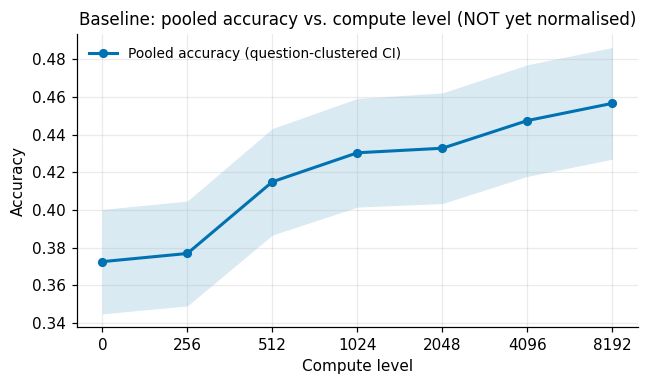

**Observed.** Pooled accuracy moves from 37.3% at `0` to 45.7% at `8192`. Mean design effect = 3.7, i.e. naive intervals would be about 1.9x too narrow. All levels contain the same number of benchmarks, but benchmark *mix by row count* may still differ (Section 5).

In [94]:
base = pooled_cluster(d)
base["benchmarks"] = d.groupby("compute_level")["benchmark"].nunique().reindex(LEVELS)
base["naive_ci_halfwidth"] = Z * base["naive_se"]
base["cluster_ci_halfwidth"] = Z * base["se"]
base.index = LV
display(base[["n_rows", "n_questions", "benchmarks", "accuracy", "ci_low", "ci_high",
              "naive_ci_halfwidth", "cluster_ci_halfwidth", "design_effect"]])

fig, ax = plt.subplots(figsize=(6, 3.6))
draw(ax, base.accuracy.values, base.ci_low.values, base.ci_high.values, color=PALETTE[0], label="Pooled accuracy (question-clustered CI)")
level_axis(ax)
ax.set_ylabel("Accuracy")
ax.set_title("Baseline: pooled accuracy vs. compute level (NOT yet normalised)")
ax.legend()
finish(fig, "02_pooled_baseline")

changing = base["benchmarks"].nunique() > 1
md(f"**Observed.** Pooled accuracy moves from {pct(base.accuracy.iloc[0])} at `{LV[0]}` to {pct(base.accuracy.iloc[-1])} at `{LV[-1]}`. "
   f"Mean design effect = {base.design_effect.mean():.1f}, i.e. naive intervals would be about {math.sqrt(base.design_effect.mean()):.1f}x too narrow. "
   + ("**The number of benchmarks observed differs across levels** "
      f"({', '.join(f'{lv}: {n:.0f}' for lv, n in base.benchmarks.items())}), so this curve mixes benchmark effects with compute effects — do not interpret it causally; see Section 5."
      if changing else "All levels contain the same number of benchmarks, but benchmark *mix by row count* may still differ (Section 5)."))

## 3. Per-benchmark behaviour

Each benchmark is analysed separately, which makes benchmark size and difficulty irrelevant to the comparison. For every benchmark we show:

* **solid line** – accuracy at each level using all available questions;
* **dashed line** – accuracy using only questions observed at *every* level (identical questions → a like-for-like comparison; shown only when it differs);
* **shaded band** – 95 % question-bootstrap interval; **dotted grey line** – chance level where inferable.

The *change from the lowest to the highest level* is estimated on identical questions only, with a paired bootstrap interval.

Two estimation objects are built here and reused later: `est_all` (all questions) and `est_bal` (same questions at every level). `PRIMARY` is the balanced one unless no question is observed at every level.

In [95]:
VALUES = [v for v in ["correct", "tokens_used", "thinking_tokens", "output_tokens", "latency_s"] if d[v].notna().any()]
est_all = estimate(d, VALUES, ["benchmark"], balanced=False)
est_bal = estimate(d, VALUES, ["benchmark"], balanced=True)
if est_bal is None:
    print("WARNING: no question is observed at every compute level; falling back to all available questions.")
PRIMARY = est_bal if est_bal is not None else est_all

# How much data does the same-question restriction keep?
bal_q = pd.Series({c[0]: n for c, n in zip(est_bal.cells, est_bal.nq)}) if est_bal is not None else pd.Series(dtype=float)
all_q = pd.Series({c[0]: n for c, n in zip(est_all.cells, est_all.nq)})
retain = pd.DataFrame({"questions (any level)": all_q, "questions (all levels)": bal_q}).fillna(0).astype(int)
retain["kept_%"] = 100 * retain.iloc[:, 1] / retain.iloc[:, 0]
print("Questions retained for the same-question (primary) estimate:")
display(retain)
excluded = retain.index[retain.iloc[:, 1] == 0].tolist()
if excluded:
    print("Benchmarks with NO question observed at every level (absent from the primary curve):", excluded)

Questions retained for the same-question (primary) estimate:


,questions (any level),questions (all levels),kept_%
AIME2025,30,30,100.000
BFCL-v3-simple,100,100,100.000
GPQA-Diamond,100,100,100.000
GSM8K,100,100,100.000
IFEval,100,100,100.000
LiveCodeBench-v6,100,100,100.000
MATH-full,100,100,100.000
MMLU-Pro,100,100,100.000
MMLU-Redux,100,100,100.000


In [96]:
vi = est_all.values.index("correct")
rows, drows = [], []
for cell in est_all.cells:
    b = cell[0]
    i = est_all.cells.index(cell)
    p, lo, hi = cell_curve(est_all, cell, "correct")
    row = {"benchmark": b, "format": bench_format.get(b), "questions": est_all.nq[i]}
    row.update({lv: v for lv, v in zip(LV, p)})
    row["peak_level"] = LV[int(np.nanargmax(p))]
    row["low_n"] = bool((q_cov.loc[b] < MIN_QUESTIONS_PER_CELL).any())
    drow = {"benchmark": b, "questions_same_set": 0, "delta": np.nan, "ci_low": np.nan, "ci_high": np.nan, "verdict": "n/a (no common questions)"}
    if est_bal is not None and cell in est_bal.cells:
        j = est_bal.cells.index(cell)
        bd = est_bal.boot[:, j, vi, -1] - est_bal.boot[:, j, vi, 0]
        lo_d, hi_d = _ci(bd)
        dl = est_bal.point[j, vi, -1] - est_bal.point[j, vi, 0]
        drow.update(questions_same_set=est_bal.nq[j], delta=dl, ci_low=lo_d, ci_high=hi_d, verdict=sig(lo_d, hi_d))
    drows.append(drow)
    rows.append(row)

bench_tbl = pd.DataFrame(rows).set_index("benchmark")
bench_delta = pd.DataFrame(drows).set_index("benchmark")
print("Accuracy per benchmark and compute level (all available questions):")
display(bench_tbl)
print(f"Change from '{LV[0]}' to '{LV[-1]}' on identical questions (percentage-point change as a fraction; 95% paired bootstrap CI):")
display(bench_delta)

Accuracy per benchmark and compute level (all available questions):


,format,questions,0,256,512,1024,2048,4096,8192,peak_level,low_n
benchmark,,,,,,,,,,,
AIME2025,Open-ended,30,0.013,0.020,0.007,0.047,0.060,0.107,0.100,4096,False
BFCL-v3-simple,Open-ended,100,0.376,0.324,0.330,0.338,0.320,0.352,0.320,0,False
GPQA-Diamond,MCQ,100,0.248,0.274,0.298,0.284,0.274,0.234,0.252,512,False
GSM8K,Open-ended,100,0.598,0.642,0.722,0.760,0.768,0.804,0.818,8192,False
IFEval,Open-ended,100,0.570,0.612,0.616,0.586,0.598,0.604,0.588,512,False
LiveCodeBench-v6,Open-ended,100,0.008,0.012,0.016,0.022,0.024,0.022,0.034,8192,False
MATH-full,Open-ended,100,0.572,0.592,0.646,0.742,0.716,0.742,0.758,8192,False
MMLU-Pro,MCQ,100,0.310,0.258,0.336,0.392,0.408,0.450,0.502,8192,False
MMLU-Redux,MCQ,100,0.406,0.408,0.478,0.434,0.466,0.474,0.488,8192,False


Change from '0' to '8192' on identical questions (percentage-point change as a fraction; 95% paired bootstrap CI):


,questions_same_set,delta,ci_low,ci_high,verdict
benchmark,,,,,
AIME2025,30,0.087,0.013,0.180,increase
BFCL-v3-simple,100,-0.056,-0.110,-0.002,decrease
GPQA-Diamond,100,0.004,-0.050,0.062,no clear change
GSM8K,100,0.220,0.156,0.284,increase
IFEval,100,0.018,-0.034,0.072,no clear change
LiveCodeBench-v6,100,0.026,0.004,0.058,increase
MATH-full,100,0.186,0.110,0.262,increase
MMLU-Pro,100,0.192,0.120,0.264,increase
MMLU-Redux,100,0.082,0.026,0.138,increase


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\03_per_benchmark.png


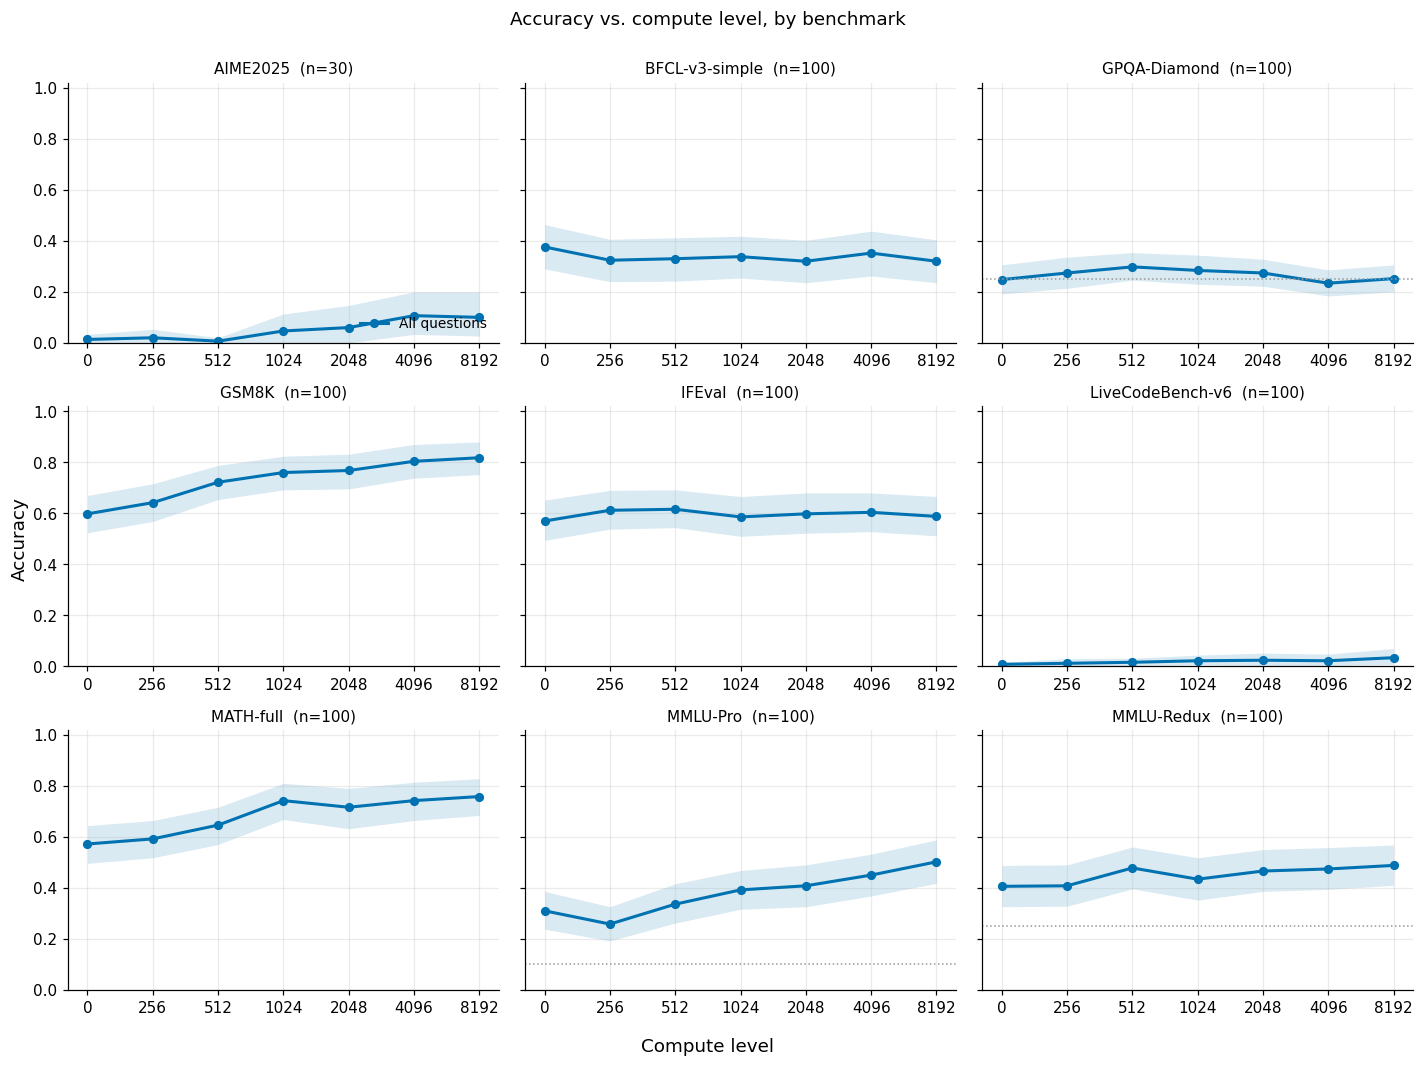

**Observed.** Between `0` and `8192`, on identical questions: 6 benchmark(s) show a credible increase, 1 a credible decrease, and 2 no clear change (95% interval includes 0). Benchmarks with a `low_n` flag should be read with extra caution.

**Hypotheses (not tested here).** Flat benchmarks may be near a ceiling or floor (chance level), or may measure knowledge that extra reasoning cannot supply; benchmarks that decline may suffer from over-thinking or from truncation at high compute (Section 11).

In [97]:
cells = est_all.cells
C = len(cells)
ncols = min(3, C)
nrows = math.ceil(C / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.2 * nrows), sharey=True, squeeze=False)
for ax in axes.ravel()[C:]:
    ax.axis("off")
for ax, cell in zip(axes.ravel(), cells):
    b = cell[0]
    p, lo, hi = cell_curve(est_all, cell, "correct")
    draw(ax, p, lo, hi, color=PALETTE[0], label="All questions")
    if est_bal is not None and cell in est_bal.cells:
        pb, lb, hb = cell_curve(est_bal, cell, "correct")
        if not np.allclose(pb, p, equal_nan=True):
            draw(ax, pb, lb, hb, color=PALETTE[3], ls="--", marker="s", band=False, label="Same questions at all levels")
    if b in CHANCE:
        ax.axhline(CHANCE[b], color="#999999", ls=":", lw=1)
    ax.set_title(f"{b}  (n={est_all.nq[est_all.cells.index(cell)]})", fontsize=10)
    level_axis(ax, label=False)
    ax.set_ylim(0, 1.02)
axes.ravel()[0].legend(loc="lower right")
fig.supxlabel("Compute level")
fig.supylabel("Accuracy")
fig.suptitle("Accuracy vs. compute level, by benchmark", y=1.0)
finish(fig, "03_per_benchmark")

v = bench_delta["verdict"].value_counts()
md(f"**Observed.** Between `{LV[0]}` and `{LV[-1]}`, on identical questions: "
   f"{v.get('increase', 0)} benchmark(s) show a credible increase, {v.get('decrease', 0)} a credible decrease, "
   f"and {v.get('no clear change', 0)} no clear change (95% interval includes 0)"
   + (f"; {v.get('n/a (no common questions)', 0)} could not be assessed." if v.get('n/a (no common questions)', 0) else ".")
   + " Benchmarks with a `low_n` flag should be read with extra caution.\n\n"
   "**Hypotheses (not tested here).** Flat benchmarks may be near a ceiling or floor (chance level), or may measure knowledge that extra reasoning cannot supply; "
   "benchmarks that decline may suffer from over-thinking or from truncation at high compute (Section 11).")

## 4. Scaling across task types

Task types (open-ended, MCQ, True/False, ...) typically differ in chance level and headroom, so their *accuracy levels* are not directly comparable, but their *scaling shape* can be. Each task type is summarised by a **macro-average over its benchmarks** (equal weight per benchmark), which stops a single large benchmark from defining the type. Row-pooled accuracy is overlaid for reference. Thin lines are the individual benchmarks — their spread shows how much of a "type effect" is really benchmark heterogeneity.

If a type contains only one benchmark, its curve cannot be separated from that benchmark's idiosyncrasies; this is flagged below.

In [98]:
has_tt = (d["task_type"] != "unknown").any()
use_column = TASK_TYPE_SOURCE == "column" or (TASK_TYPE_SOURCE == "auto" and has_tt)
if use_column:
    d["task_type_final"] = d["task_type"].replace(TASK_TYPE_MAP or {})
    print("Task types taken from the `task_type` column:", sorted(d.task_type_final.unique()))
else:
    d["task_type_final"] = d["benchmark"].map(bench_format).fillna("unknown")
    print("Task types INFERRED from `gold` (task_type column absent or uninformative):", sorted(d.task_type_final.unique()))

# Sanity check: does the declared type agree with the inferred answer format?
if use_column:
    chk = pd.crosstab(d.drop_duplicates("benchmark").set_index("benchmark")["task_type_final"], bench_format.rename("inferred format"))
    print("Declared task type (rows) vs. format inferred from gold (columns), counted in benchmarks:")
    display(chk)

est_tt = estimate(d, ["correct"], ["benchmark", "task_type_final"], balanced=True)
types = sorted({c[1] for c in est_tt.cells}) if est_tt is not None else []
tt_rows, tt_curves = [], {}
for t in types:
    cv = macro(est_tt, "correct", where=lambda c, t=t: c[1] == t)
    if cv is None:
        continue
    tt_curves[t] = cv
    pooled_t = pooled_cluster(d[d.task_type_final == t])["accuracy"].values
    dl, lo, hi = cv.diff(0, -1)
    row = {"task_type": t, "benchmarks": len(cv.cells), "questions": int(sum(est_tt.nq[est_tt.cells.index(c)] for c in cv.cells))}
    row.update({f"macro@{lv}": v for lv, v in zip(LV, cv.point)})
    row.update({f"pooled@{lv}": v for lv, v in zip(LV, pooled_t)})
    row.update({"delta_macro": dl, "ci_low": lo, "ci_high": hi, "verdict": sig(lo, hi)})
    tt_rows.append(row)
tt_tbl = pd.DataFrame(tt_rows).set_index("task_type")
display(tt_tbl)
single = [t for t, cv in tt_curves.items() if len(cv.cells) == 1]
if single:
    print("NOTE: task types backed by a single benchmark (type effect indistinguishable from benchmark effect):", single)
skipped = sorted({c[0] for c in est_all.cells} - {c[0] for c in (est_tt.cells if est_tt else [])})
if skipped:
    print("Benchmarks without questions observed at every level, absent from this section:", skipped)

Task types INFERRED from `gold` (task_type column absent or uninformative): ['MCQ', 'Open-ended']


,benchmarks,questions,macro@0,macro@256,macro@512,macro@1024,macro@2048,macro@4096,macro@8192,pooled@0,pooled@256,pooled@512,pooled@1024,pooled@2048,pooled@4096,pooled@8192,delta_macro,ci_low,ci_high,verdict
task_type,,,,,,,,,,,,,,,,,,,,
MCQ,3,300,0.321,0.313,0.371,0.370,0.383,0.386,0.414,0.321,0.313,0.371,0.370,0.383,0.386,0.414,0.093,0.059,0.129,increase
Open-ended,6,530,0.356,0.367,0.389,0.416,0.414,0.438,0.436,0.402,0.413,0.440,0.465,0.461,0.482,0.481,0.080,0.055,0.105,increase


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\04_task_types_levels.png


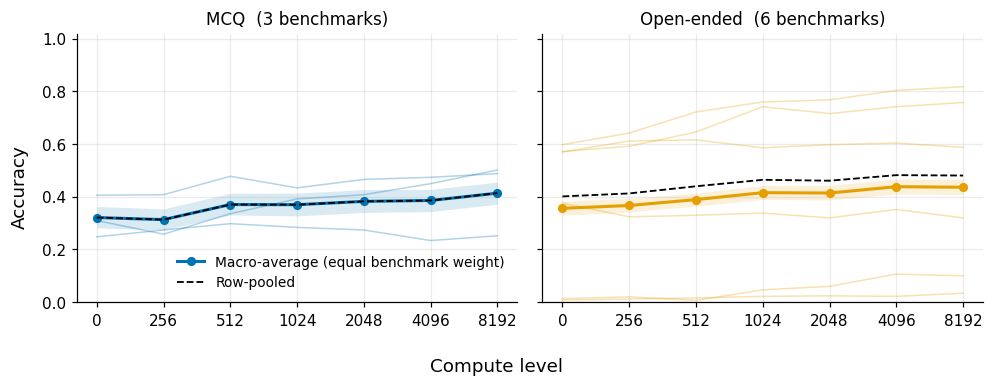

Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\04_task_types_gain.png


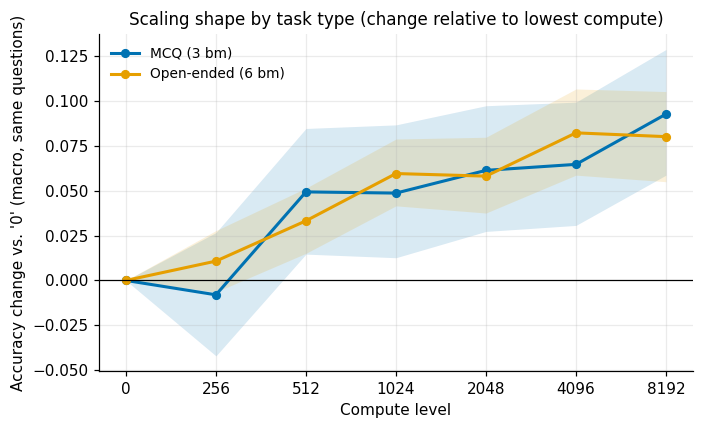

**Observed.** Macro-averaged change from `0` to `8192` (95% CI): MCQ: +9.3 pp [+5.9 pp, +12.9 pp]; Open-ended: +8.0 pp [+5.5 pp, +10.5 pp].

Types whose intervals do not overlap scale differently in this sample; overlapping intervals do **not** prove equal scaling, only that the data cannot distinguish them. **Hypotheses:** MCQ and True/False have a chance floor and limited headroom, which compresses their gains; open-ended tasks may gain more because multi-step reasoning matters more.

In [99]:
T = len(tt_curves)
if T:
    ncols = min(3, T)
    nrows = math.ceil(T / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.5 * nrows), sharey=True, squeeze=False)
    for ax in axes.ravel()[T:]:
        ax.axis("off")
    for k, (ax, (t, cv)) in enumerate(zip(axes.ravel(), tt_curves.items())):
        col = PALETTE[k % len(PALETTE)]
        for c in cv.cells:                                   # individual benchmarks
            ax.plot(X, est_tt.point[est_tt.cells.index(c), 0], color=col, alpha=0.3, lw=1)
        draw(ax, cv.point, cv.lo, cv.hi, color=col, label="Macro-average (equal benchmark weight)")
        pooled_t = pooled_cluster(d[d.task_type_final == t])["accuracy"].values
        ax.plot(X, pooled_t, color="black", ls="--", lw=1.2, label="Row-pooled")
        ax.set_title(f"{t}  ({len(cv.cells)} benchmark{'s' if len(cv.cells) != 1 else ''})")
        level_axis(ax, label=False)
        ax.set_ylim(0, 1.02)
    axes.ravel()[0].legend(loc="lower right")
    fig.supxlabel("Compute level")
    fig.supylabel("Accuracy")
    finish(fig, "04_task_types_levels")

    fig, ax = plt.subplots(figsize=(6.5, 4))
    for k, (t, cv) in enumerate(tt_curves.items()):
        r = cv.rel()
        draw(ax, r.point, r.lo, r.hi, color=PALETTE[k % len(PALETTE)], label=f"{t} ({len(cv.cells)} bm)")
    ax.axhline(0, color="black", lw=0.8)
    level_axis(ax)
    ax.set_ylabel(f"Accuracy change vs. '{LV[0]}' (macro, same questions)")
    ax.set_title("Scaling shape by task type (change relative to lowest compute)")
    ax.legend()
    finish(fig, "04_task_types_gain")

    obs = "; ".join(f"{t}: {pp(r.delta_macro)} [{pp(r.ci_low)}, {pp(r.ci_high)}]" for t, r in tt_tbl.iterrows())
    md(f"**Observed.** Macro-averaged change from `{LV[0]}` to `{LV[-1]}` (95% CI): {obs}.\n\n"
       "Types whose intervals do not overlap scale differently in this sample; overlapping intervals do **not** prove equal scaling, only that the data cannot distinguish them. "
       "**Hypotheses:** MCQ and True/False have a chance floor and limited headroom, which compresses their gains; open-ended tasks may gain more because multi-step reasoning matters more.")
else:
    print("No task-type curves could be computed.")

## 5. The overall accuracy-vs-compute curve (normalised)

Four versions of the overall curve are compared. They answer progressively fairer questions:

1. **Pooled, all rows** – every row equal; large benchmarks dominate; benchmark mix may change with compute.
2. **Macro, all available benchmarks** – benchmarks equal, but the *set* of benchmarks can change along the curve (a hard benchmark that only appears at high compute drags the curve down).
3. **Macro, full-coverage benchmarks** – the same benchmarks at every level, all their questions.
4. **Macro, full-coverage benchmarks, same questions at every level (primary)** – like-for-like at the question level too.

If (1) and (4) disagree — especially in *direction* — the pooled curve is confounded by composition (Simpson's paradox) and should not be used.

In [100]:
pooled = pooled_cluster(d)
c_pooled = (pooled["accuracy"].values, pooled["ci_low"].values, pooled["ci_high"].values)
m_avail = macro(est_all, "correct", full_only=False)
m_full = macro(est_all, "correct", full_only=True)
m_primary = macro(PRIMARY, "correct", full_only=True)
if m_primary is None:
    raise RuntimeError("No benchmark is observed at every compute level; a level-comparable macro curve cannot be built. "
                       "Inspect the coverage table in Section 1.1.")

agg = pd.DataFrame({"pooled": c_pooled[0], "macro_all_available": m_avail.point,
                    "macro_full_coverage": m_full.point if m_full else np.nan,
                    "macro_primary": m_primary.point,
                    "primary_ci_low": m_primary.lo, "primary_ci_high": m_primary.hi,
                    "benchmarks_in_all_available": m_avail.n_cells}, index=LV)
display(agg)
print(f"Primary curve uses {len(m_primary.cells)} benchmark(s): {[c[0] for c in m_primary.cells]}")
dropped_from_primary = sorted({c[0] for c in est_all.cells} - {c[0] for c in m_primary.cells})
if dropped_from_primary:
    print("Not in the primary curve (missing at >= 1 level, or no common questions):", dropped_from_primary)

,pooled,macro_all_available,macro_full_coverage,macro_primary,primary_ci_low,primary_ci_high,benchmarks_in_all_available
0,0.373,0.345,0.345,0.345,0.323,0.367,9
256,0.377,0.349,0.349,0.349,0.327,0.372,9
512,0.415,0.383,0.383,0.383,0.363,0.404,9
1024,0.430,0.401,0.401,0.401,0.379,0.424,9
2048,0.433,0.404,0.404,0.404,0.381,0.429,9
4096,0.447,0.421,0.421,0.421,0.398,0.445,9
8192,0.457,0.429,0.429,0.429,0.405,0.453,9


Primary curve uses 9 benchmark(s): ['AIME2025', 'BFCL-v3-simple', 'GPQA-Diamond', 'GSM8K', 'IFEval', 'LiveCodeBench-v6', 'MATH-full', 'MMLU-Pro', 'MMLU-Redux']


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\05_aggregate.png


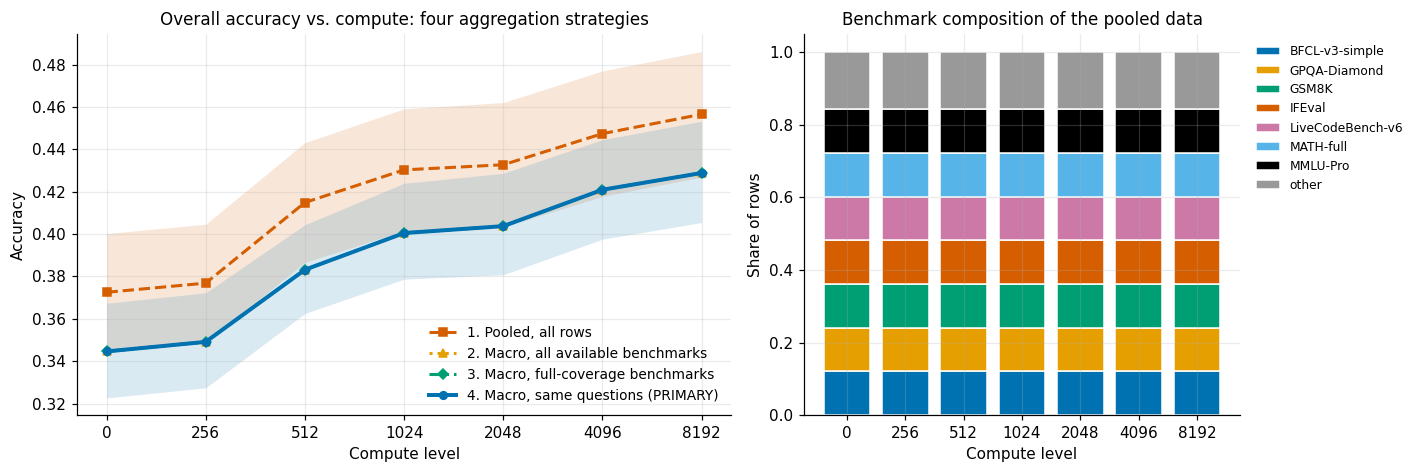

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
draw(ax, *c_pooled, color=PALETTE[3], label="1. Pooled, all rows", ls="--", marker="s")
draw(ax, m_avail.point, m_avail.lo, m_avail.hi, color=PALETTE[1], label="2. Macro, all available benchmarks", ls=":", marker="^", band=False)
if m_full:
    draw(ax, m_full.point, m_full.lo, m_full.hi, color=PALETTE[2], label="3. Macro, full-coverage benchmarks", ls="-.", marker="D", band=False)
draw(ax, m_primary.point, m_primary.lo, m_primary.hi, color=PALETTE[0], label="4. Macro, same questions (PRIMARY)", lw=2.6)
level_axis(ax)
ax.set_ylabel("Accuracy")
ax.set_title("Overall accuracy vs. compute: four aggregation strategies")
ax.legend(loc="best")

# Composition of the pooled data: share of rows by benchmark at each level
share = d.groupby(["compute_level", "benchmark"]).size().unstack("benchmark").reindex(LEVELS).fillna(0)
share = share.div(share.sum(axis=1), axis=0)
if share.shape[1] > 8:
    top = share.mean().nlargest(7).index
    share = pd.concat([share[top], share.drop(columns=top).sum(axis=1).rename("other")], axis=1)
bottom = np.zeros(L)
for k, b in enumerate(share.columns):
    axes[1].bar(X, share[b].values, bottom=bottom, label=b, color=PALETTE[k % len(PALETTE)], edgecolor="white", linewidth=1)
    bottom += share[b].values
level_axis(axes[1])
axes[1].set_ylabel("Share of rows")
axes[1].set_title("Benchmark composition of the pooled data")
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
finish(fig, "05_aggregate")

In [102]:
# ----------------------- Simpson's-paradox diagnostics --------------------
dp = pooled["accuracy"].iloc[-1] - pooled["accuracy"].iloc[0]
dm, dm_lo, dm_hi = m_primary.diff(0, -1)
tv = 0.5 * np.abs(d.groupby(["compute_level", "benchmark"]).size().unstack().reindex(LEVELS).fillna(0)
                  .pipe(lambda x: x.div(x.sum(axis=1), axis=0)).iloc[[0, -1]].diff().iloc[-1]).sum()
inside = bench_delta.dropna(subset=["delta"])
same_dir = (np.sign(inside["delta"]) == np.sign(dp)).mean() if len(inside) else np.nan
simpson_flag = bool(np.sign(dp) != np.sign(dm) and abs(dp) > 0 and abs(dm) > 0)

md(f"**Pooled change** `{LV[0]}` -> `{LV[-1]}`: {pp(dp)}.  **Primary (macro, same-question) change:** {pp(dm)} [95% CI {pp(dm_lo)}, {pp(dm_hi)}].  "
   f"**Gap (pooled - macro):** {pp(dp - dm)}.\n\n"
   f"Benchmark-mix shift between the lowest and highest level (total-variation distance of row shares): **{tv:.2f}** (0 = identical mix, 1 = disjoint).  "
   f"Share of benchmarks whose own change has the same sign as the pooled change: **{same_dir:.0%}**.\n\n"
   + ("**Simpson-type reversal detected:** the pooled and the normalised curves move in opposite directions. The pooled trend reflects changing benchmark composition, not a compute effect."
      if simpson_flag else
      "No sign reversal between the pooled and the primary change. A non-trivial gap can still exist (see the gap above); the primary estimate is the one to quote."))

**Pooled change** `0` -> `8192`: +8.4 pp.  **Primary (macro, same-question) change:** +8.4 pp [95% CI +6.5 pp, +10.6 pp].  **Gap (pooled - macro):** -0.0 pp.

Benchmark-mix shift between the lowest and highest level (total-variation distance of row shares): **0.00** (0 = identical mix, 1 = disjoint).  Share of benchmarks whose own change has the same sign as the pooled change: **89%**.

No sign reversal between the pooled and the primary change. A non-trivial gap can still exist (see the gap above); the primary estimate is the one to quote.

Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\05_leave_one_out.png


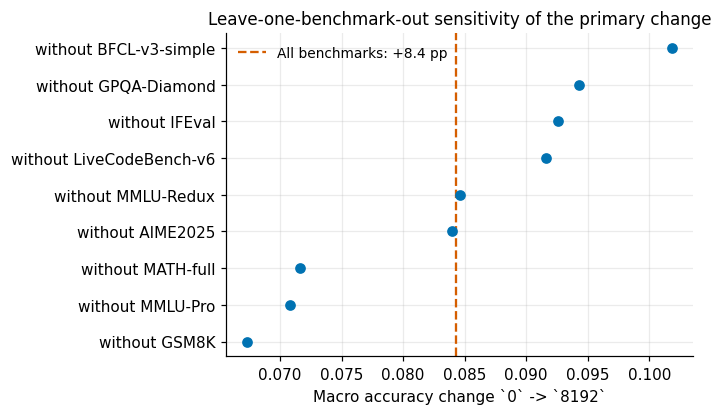

**Observed.** Dropping any single benchmark moves the primary change within [+6.7 pp, +10.2 pp] (full set: +8.4 pp). A wide range means the aggregate rests on a few benchmarks.

In [103]:
# --------- Does any single benchmark drive the aggregate? (leave-one-out) ---------
vi = PRIMARY.values.index("correct")
sel = [PRIMARY.cells.index(c) for c in m_primary.cells]
full_delta = m_primary.point[-1] - m_primary.point[0]
loo = {}
if len(sel) > 1:
    for i in sel:
        rest = [k for k in sel if k != i]
        pts = PRIMARY.point[rest, vi, :].mean(axis=0)
        loo[PRIMARY.cells[i][0]] = pts[-1] - pts[0]
    loo = pd.Series(loo).sort_values()
    fig, ax = plt.subplots(figsize=(6.5, max(2.5, 0.32 * len(loo) + 1)))
    ax.scatter(loo.values, range(len(loo)), color=PALETTE[0], zorder=3)
    ax.axvline(full_delta, color=PALETTE[3], ls="--", label=f"All benchmarks: {pp(full_delta)}")
    ax.set_yticks(range(len(loo)))
    ax.set_yticklabels([f"without {b}" for b in loo.index])
    ax.set_xlabel(f"Macro accuracy change `{LV[0]}` -> `{LV[-1]}`")
    ax.set_title("Leave-one-benchmark-out sensitivity of the primary change")
    ax.legend()
    finish(fig, "05_leave_one_out")
    md(f"**Observed.** Dropping any single benchmark moves the primary change within [{pp(loo.min())}, {pp(loo.max())}] (full set: {pp(full_delta)}). "
       "A wide range means the aggregate rests on a few benchmarks.")
else:
    print("Only one benchmark in the primary curve; leave-one-out is not informative.")

## 6. Diminishing returns

Does each additional compute level buy the same accuracy? We compute the **step-wise gain** between adjacent levels on the primary (macro, same-question) curve with paired bootstrap intervals, and show the same step-wise gains for each benchmark as a heat map (`*` = interval excludes zero). Levels are treated as ordered categories; if the steps are not equally spaced in actual compute, "diminishing" refers to *per level*, and Section 9 re-expresses the gains per token and per second.

,gain,ci_low,ci_high,verdict,share_of_total_gain
step,,,,,
0 -> 256,0.005,-0.011,0.021,no clear change,0.054
256 -> 512,0.034,0.021,0.048,increase,0.404
512 -> 1024,0.017,0.004,0.032,increase,0.206
1024 -> 2048,0.003,-0.010,0.016,no clear change,0.039
2048 -> 4096,0.017,0.003,0.031,increase,0.204
4096 -> 8192,0.008,-0.004,0.019,no clear change,0.094


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\06_diminishing_returns.png


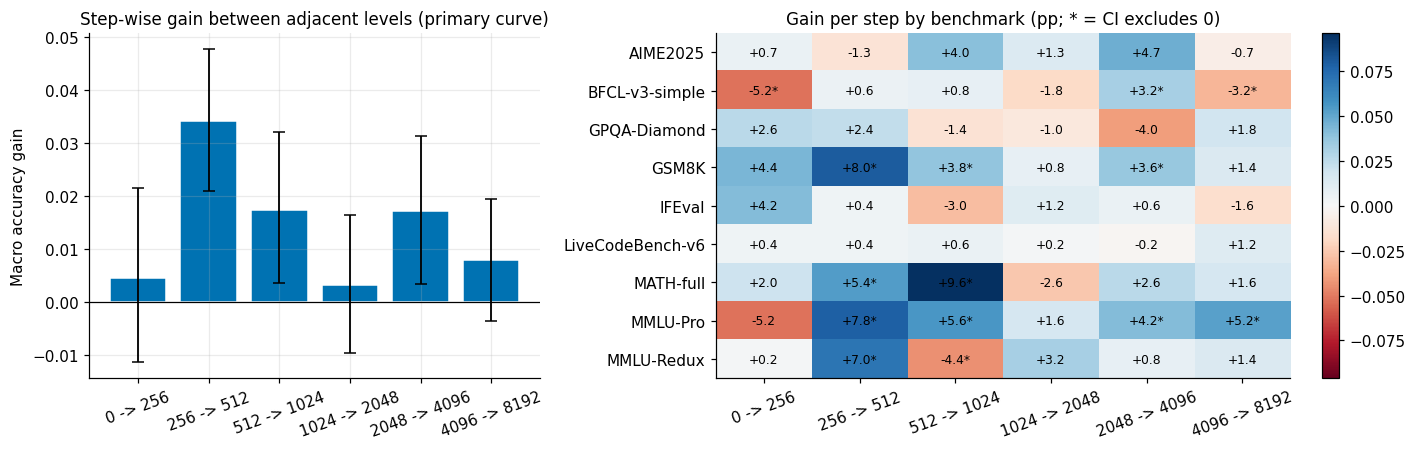

**Observed.** The first step (0 -> 256) adds +0.5 pp [-1.1 pp, +2.1 pp]; the last step (4096 -> 8192) adds +0.8 pp [-0.4 pp, +1.9 pp]. 8 of 9 benchmark(s) show a decrease in at least one step (point estimate; may be noise for small benchmarks).

**How to read.** Shrinking gains across steps with intervals that increasingly include zero are consistent with diminishing returns. Overlapping intervals for first and last step do not by themselves show the gains are equal. **Hypothesis:** later steps help mainly on the hardest questions, which are few.

In [104]:
steps = []
for j in range(L - 1):
    dl, lo, hi = m_primary.diff(j, j + 1)
    steps.append({"step": f"{LV[j]} -> {LV[j + 1]}", "gain": dl, "ci_low": lo, "ci_high": hi, "verdict": sig(lo, hi)})
step_tbl = pd.DataFrame(steps).set_index("step")
total_gain = m_primary.point[-1] - m_primary.point[0]
step_tbl["share_of_total_gain"] = step_tbl["gain"] / total_gain if total_gain > 0 else np.nan   # only meaningful when the overall change is positive
display(step_tbl)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.4]})
ax = axes[0]
g = step_tbl["gain"].values
ax.bar(range(L - 1), g, color=[PALETTE[0] if x >= 0 else PALETTE[3] for x in g], edgecolor="white")
ax.errorbar(range(L - 1), g, yerr=[g - step_tbl.ci_low.values, step_tbl.ci_high.values - g], fmt="none", ecolor="black", capsize=4, lw=1.2)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(L - 1))
ax.set_xticklabels(step_tbl.index, rotation=20)
ax.set_ylabel("Macro accuracy gain")
ax.set_title("Step-wise gain between adjacent levels (primary curve)")

M = np.full((len(sel), L - 1), np.nan)
S = np.zeros_like(M, dtype=bool)
for r, i in enumerate(sel):
    for j in range(L - 1):
        bd = PRIMARY.boot[:, i, vi, j + 1] - PRIMARY.boot[:, i, vi, j]
        lo, hi = _ci(bd)
        M[r, j] = PRIMARY.point[i, vi, j + 1] - PRIMARY.point[i, vi, j]
        S[r, j] = lo > 0 or hi < 0
vmax = max(np.nanmax(np.abs(M)), 1e-6)
ax = axes[1]
im = ax.imshow(M, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
for r in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, r, f"{100 * M[r, j]:+.1f}{'*' if S[r, j] else ''}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(L - 1))
ax.set_xticklabels(step_tbl.index, rotation=20)
ax.set_yticks(range(len(sel)))
ax.set_yticklabels([PRIMARY.cells[i][0] for i in sel])
ax.grid(False)
ax.set_title("Gain per step by benchmark (pp; * = CI excludes 0)")
fig.colorbar(im, ax=ax, fraction=0.04)
finish(fig, "06_diminishing_returns")

first, last_ = step_tbl.iloc[0], step_tbl.iloc[-1]
nonmono = int((M < 0).any(axis=1).sum())
md(f"**Observed.** The first step ({step_tbl.index[0]}) adds {pp(first.gain)} [{pp(first.ci_low)}, {pp(first.ci_high)}]; "
   f"the last step ({step_tbl.index[-1]}) adds {pp(last_.gain)} [{pp(last_.ci_low)}, {pp(last_.ci_high)}]. "
   f"{nonmono} of {len(sel)} benchmark(s) show a decrease in at least one step (point estimate; may be noise for small benchmarks).\n\n"
   "**How to read.** Shrinking gains across steps with intervals that increasingly include zero are consistent with diminishing returns. "
   "Overlapping intervals for first and last step do not by themselves show the gains are equal. **Hypothesis:** later steps help mainly on the hardest questions, which are few.")

## 7. Difficulty effects

Does extra compute help easy, medium or hard questions most? Each *benchmark x difficulty-tier* is a cell; tiers are summarised by a macro-average over the benchmarks that contain them (equal weight per benchmark), on identical questions across levels. **Caveat:** difficulty tiers are usually defined *within* each benchmark, so "hard" in one benchmark is not guaranteed to match "hard" in another, and some benchmarks may lack some tiers (the number of benchmarks per tier is shown).

In [105]:
tiers_present = d["difficulty_tier"].unique().tolist()
if tiers_present == ["unknown"]:
    print("No usable difficulty_tier information; this section is skipped.")
    dt_curves = {}
else:
    def order_tiers(tiers):
        if TIER_ORDER is not None:
            return [t for t in TIER_ORDER if t in tiers] + [t for t in tiers if t not in TIER_ORDER]
        known = ["trivial", "very easy", "easy", "medium", "moderate", "hard", "very hard", "expert"]
        low = {t: str(t).lower() for t in tiers}
        if all(v in known for v in low.values()):
            return sorted(tiers, key=lambda t: known.index(low[t]))
        nums = {t: re.findall(r"\d+", str(t)) for t in tiers}
        if all(nums.values()):
            return sorted(tiers, key=lambda t: int(nums[t][0]))
        return sorted(tiers, key=str)

    tier_order = order_tiers([t for t in tiers_present if t != "unknown"])
    dtv = ["correct"] + (["thinking_tokens"] if d["thinking_tokens"].notna().any() else (["tokens_used"] if d["tokens_used"].notna().any() else []))
    est_dt = estimate(d[d.difficulty_tier != "unknown"], dtv, ["benchmark", "difficulty_tier"], balanced=True)
    dt_curves, dt_tok, rows = {}, {}, []
    for t in tier_order:
        cv = macro(est_dt, "correct", where=lambda c, t=t: c[1] == t)
        if cv is None:
            continue
        dt_curves[t] = cv
        if len(dtv) > 1:
            dt_tok[t] = macro(est_dt, dtv[1], where=lambda c, t=t: c[1] == t)
        dl, lo, hi = cv.diff(0, -1)
        row = {"tier": t, "benchmarks": len(cv.cells), "questions": int(sum(est_dt.nq[est_dt.cells.index(c)] for c in cv.cells))}
        row.update({lv: v for lv, v in zip(LV, cv.point)})
        row.update({"delta": dl, "ci_low": lo, "ci_high": hi, "verdict": sig(lo, hi)})
        rows.append(row)
    dt_tbl = pd.DataFrame(rows).set_index("tier")
    display(dt_tbl)

,benchmarks,questions,0,256,512,1024,2048,4096,8192,delta,ci_low,ci_high,verdict
tier,,,,,,,,,,,,,
easy,3,300,0.525,0.554,0.605,0.593,0.611,0.627,0.631,0.107,0.073,0.141,increase
medium,3,300,0.419,0.391,0.437,0.491,0.481,0.515,0.527,0.107,0.069,0.147,increase
hard,3,230,0.090,0.102,0.107,0.118,0.119,0.121,0.129,0.039,0.008,0.075,increase


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\07_difficulty.png


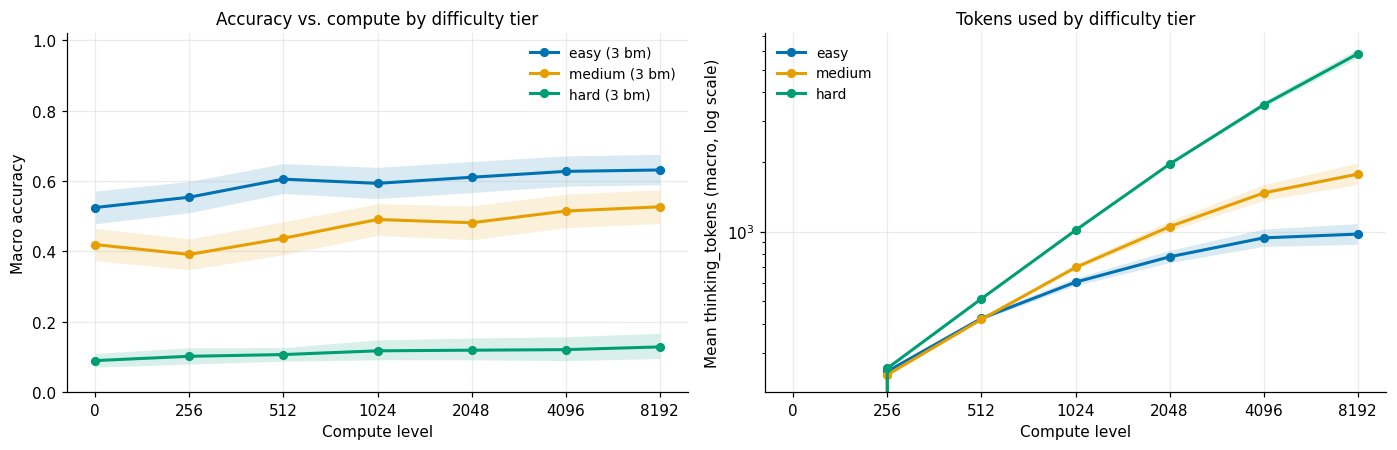

**Observed.** Macro change `0` -> `8192` by tier (95% CI): easy: +10.7 pp [+7.3 pp, +14.1 pp]; medium: +10.7 pp [+6.9 pp, +14.7 pp]; hard: +3.9 pp [+0.8 pp, +7.5 pp].

**How to read.** If harder tiers gain more, compute is buying capability where headroom exists; if easy tiers are flat near 100 %, that is a ceiling effect, not evidence that compute is useless for them. The right-hand panel shows whether the model spends more tokens on harder questions (adaptive effort) or uses a similar budget regardless. **Hypothesis:** gains concentrate in mid-difficulty tiers where the model is neither at ceiling nor hopeless.

In [106]:
if dt_curves:
    ncol = 2 if dt_tok else 1
    fig, axes = plt.subplots(1, ncol, figsize=(6.4 * ncol, 4.2), squeeze=False)
    ax = axes[0, 0]
    for k, (t, cv) in enumerate(dt_curves.items()):
        draw(ax, cv.point, cv.lo, cv.hi, color=PALETTE[k % len(PALETTE)], label=f"{t} ({len(cv.cells)} bm)")
    level_axis(ax)
    ax.set_ylabel("Macro accuracy")
    ax.set_ylim(0, 1.02)
    ax.set_title("Accuracy vs. compute by difficulty tier")
    ax.legend()
    if dt_tok:
        ax = axes[0, 1]
        for k, (t, cv) in enumerate(dt_tok.items()):
            draw(ax, cv.point, cv.lo, cv.hi, color=PALETTE[k % len(PALETTE)], label=t)
        level_axis(ax)
        ax.set_yscale("log")
        ax.set_ylabel(f"Mean {dtv[1]} (macro, log scale)")
        ax.set_title("Tokens used by difficulty tier")
        ax.legend()
    finish(fig, "07_difficulty")

    obs = "; ".join(f"{t}: {pp(r.delta)} [{pp(r.ci_low)}, {pp(r.ci_high)}]" for t, r in dt_tbl.iterrows())
    md(f"**Observed.** Macro change `{LV[0]}` -> `{LV[-1]}` by tier (95% CI): {obs}.\n\n"
       "**How to read.** If harder tiers gain more, compute is buying capability where headroom exists; if easy tiers are flat near 100 %, that is a ceiling effect, not evidence that compute is useless for them. "
       "The right-hand panel shows whether the model spends more tokens on harder questions (adaptive effort) or uses a similar budget regardless. "
       "**Hypothesis:** gains concentrate in mid-difficulty tiers where the model is neither at ceiling nor hopeless.")

## 8. Compute level vs. elapsed time

Latency is analysed on the same footing as accuracy: per-question mean latency, macro-averaged over benchmarks (same questions at every level), with question-bootstrap intervals; ratios relative to the lowest level are reported because absolute seconds depend on hardware. Distributions are also shown at row level, because mean latency is sensitive to a heavy tail.

**Assumption:** `latency_s` is the end-to-end wall-clock time per sample. If requests were batched or ran concurrently, latency reflects queueing and throughput, not pure generation speed; this cannot be verified from the data.

In [107]:
if "latency_s" not in VALUES:
    print("No usable latency_s values; this section is skipped.")
    lat = None
else:
    lat = macro(PRIMARY, "latency_s")
    lat_ratio = Curve(lat.point / lat.point[0], lat.boot / lat.boot[:, :1])
    row_lat = d.groupby("compute_level")["latency_s"]
    lat_tbl = pd.DataFrame({
        "macro_mean_s": lat.point, "ci_low": lat.lo, "ci_high": lat.hi,
        "ratio_vs_lowest": lat_ratio.point, "ratio_ci_low": lat_ratio.lo, "ratio_ci_high": lat_ratio.hi,
        "row_median_s": row_lat.median().reindex(LEVELS).values,
        "row_p90_s": row_lat.quantile(0.9).reindex(LEVELS).values,
        "row_max_s": row_lat.max().reindex(LEVELS).values,
    }, index=LV)
    display(lat_tbl)
    cv_miss = d["latency_s"].isna().groupby(d["compute_level"]).mean().reindex(LEVELS)
    if (cv_miss > 0).any():
        print("Share of rows without latency, by level:", cv_miss.round(3).to_dict())

,macro_mean_s,ci_low,ci_high,ratio_vs_lowest,ratio_ci_low,ratio_ci_high,row_median_s,row_p90_s,row_max_s
0,57.374,52.959,61.600,1.000,1.000,1.000,17.557,94.935,576.855
256,88.930,84.898,93.132,1.550,1.474,1.639,47.068,145.020,845.342
512,114.825,111.170,118.444,2.001,1.890,2.135,68.803,205.930,859.460
1024,156.473,152.667,160.449,2.727,2.559,2.922,99.984,313.093,951.420
2048,239.002,233.733,244.698,4.166,3.892,4.497,127.951,525.211,"1,198.091"
4096,377.533,366.437,388.266,6.580,6.138,7.088,140.657,955.420,"1,414.731"
8192,568.528,544.357,591.896,9.909,9.254,10.697,138.074,"1,744.847","2,094.032"


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\08_latency.png


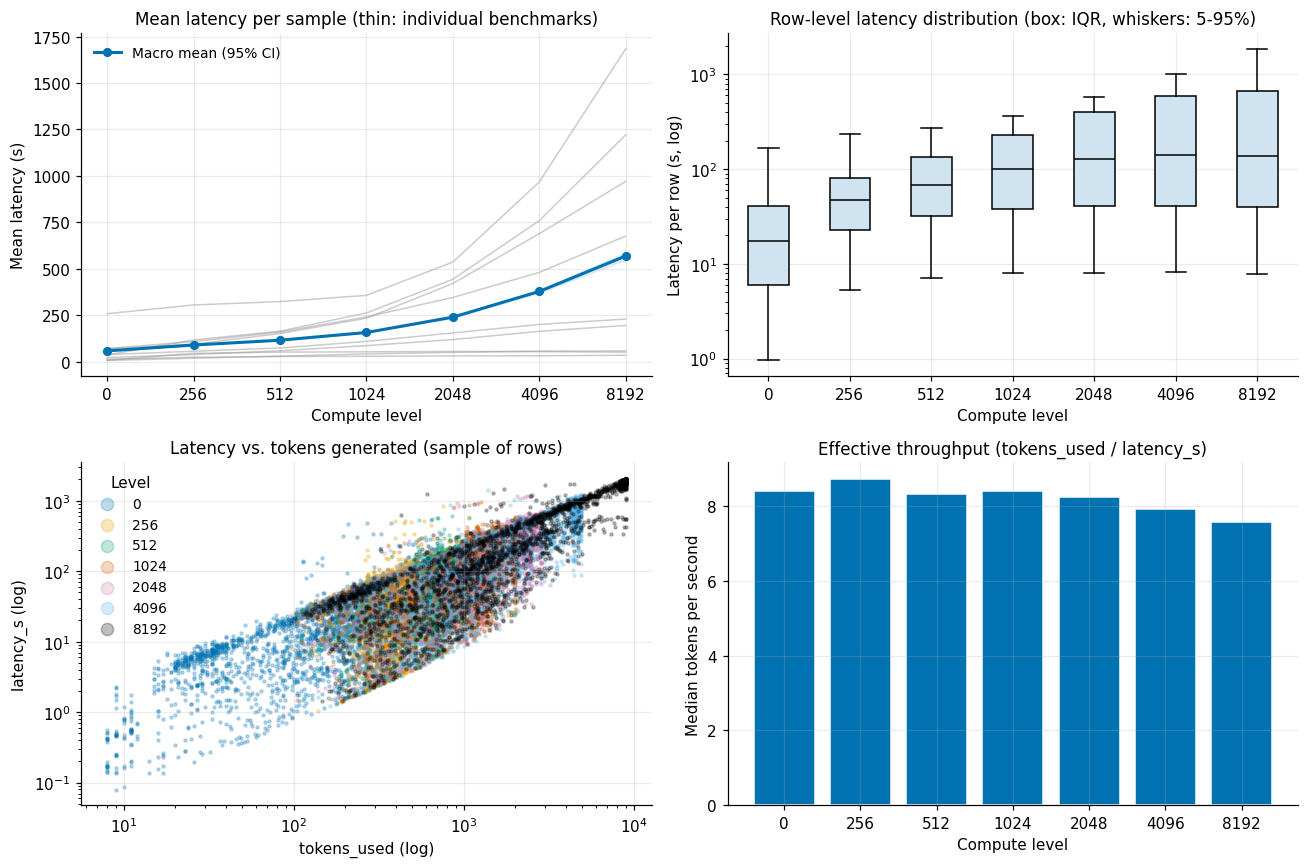

**Observed.** Macro mean latency rises from 57.4 s at `0` to 568.5 s at `8192` (9.9x; 95% CI 9.3-10.7x). Row-level Spearman correlation between tokens and latency: 0.81. Median throughput ranges from 8 to 9 tokens/s across levels.

**How to read.** Near-constant throughput together with a high token-latency correlation indicates that latency grows mainly because more tokens are generated (**hypothesis**, since hardware and batching are not recorded). Strong throughput changes between levels would suggest queueing or other overheads that confound the latency comparison.

In [108]:
if lat is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax = axes[0, 0]
    for c in lat.cells:
        ax.plot(X, PRIMARY.point[PRIMARY.cells.index(c), PRIMARY.values.index("latency_s")], color="#999999", alpha=0.5, lw=1)
    draw(ax, lat.point, lat.lo, lat.hi, color=PALETTE[0], label="Macro mean (95% CI)")
    level_axis(ax)
    ax.set_ylabel("Mean latency (s)")
    ax.set_title("Mean latency per sample (thin: individual benchmarks)")
    ax.legend()

    ax = axes[0, 1]
    groups = [d.loc[d.compute_level == lv, "latency_s"].dropna().values for lv in LEVELS]
    ax.boxplot(groups, whis=(5, 95), showfliers=False, patch_artist=True, boxprops=dict(facecolor="#cfe3f1"), medianprops=dict(color="black"))
    ax.set_xticks(range(1, L + 1))
    ax.set_xticklabels(LV)
    ax.set_yscale("log")
    ax.set_xlabel("Compute level")
    ax.set_ylabel("Latency per row (s, log)")
    ax.set_title("Row-level latency distribution (box: IQR, whiskers: 5-95%)")

    ax = axes[1, 0]
    sub = d[["tokens_used", "latency_s", "compute_level"]].dropna()
    sub = sub[(sub.tokens_used > 0) & (sub.latency_s > 0)]
    if len(sub):
        sub = sub.sample(min(len(sub), 20000), random_state=SEED)
        for k, lv in enumerate(LEVELS):
            s = sub[sub.compute_level == lv]
            ax.scatter(s.tokens_used, s.latency_s, s=4, alpha=0.25, color=PALETTE[k % len(PALETTE)], label=str(lv), rasterized=True)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.legend(markerscale=4, title="Level")
    ax.set_xlabel("tokens_used (log)")
    ax.set_ylabel("latency_s (log)")
    ax.set_title("Latency vs. tokens generated (sample of rows)")

    ax = axes[1, 1]
    tps = (d.loc[(d.tokens_used > 0) & (d.latency_s > 0)].assign(tps=lambda x: x.tokens_used / x.latency_s)
             .groupby("compute_level")["tps"].median().reindex(LEVELS))
    ax.bar(X, tps.values, color=PALETTE[0], edgecolor="white")
    level_axis(ax)
    ax.set_ylabel("Median tokens per second")
    ax.set_title("Effective throughput (tokens_used / latency_s)")
    finish(fig, "08_latency")

    rho = sub[["tokens_used", "latency_s"]].corr(method="spearman").iloc[0, 1] if len(sub) > 2 else np.nan
    md(f"**Observed.** Macro mean latency rises from {lat.point[0]:.1f} s at `{LV[0]}` to {lat.point[-1]:.1f} s at `{LV[-1]}` "
       f"({lat_ratio.point[-1]:.1f}x; 95% CI {lat_ratio.lo[-1]:.1f}-{lat_ratio.hi[-1]:.1f}x). "
       f"Row-level Spearman correlation between tokens and latency: {rho:.2f}. Median throughput ranges from {np.nanmin(tps.values):.0f} to {np.nanmax(tps.values):.0f} tokens/s across levels.\n\n"
       "**How to read.** Near-constant throughput together with a high token-latency correlation indicates that latency grows mainly because more tokens are generated "
       "(**hypothesis**, since hardware and batching are not recorded). Strong throughput changes between levels would suggest queueing or other overheads that confound the latency comparison.")

## 9. Token efficiency and the cost of accuracy

Here accuracy is related to what it costs: tokens and seconds. All quantities come from the same bootstrap replicates, so ratios are internally consistent.

* **Tokens per correct answer** = macro mean tokens / macro accuracy (expected tokens spent per success; lower is more efficient).
* **Thinking share** = thinking tokens / total tokens.
* **Marginal return** = accuracy gain per additional 1,000 tokens (or per additional second) between adjacent levels. These ratios are unstable when the denominator is small, so the underlying differences are shown beside them.

In [109]:
tok = macro(PRIMARY, "tokens_used") if "tokens_used" in VALUES else None
think = macro(PRIMARY, "thinking_tokens") if "thinking_tokens" in VALUES else None
outp = macro(PRIMARY, "output_tokens") if "output_tokens" in VALUES else None
acc = m_primary

eff = pd.DataFrame({"accuracy": acc.point}, index=LV)
if tok is not None:
    tpc = Curve(tok.point / acc.point, tok.boot / acc.boot)
    eff["mean_tokens"], eff["tokens_ci_low"], eff["tokens_ci_high"] = tok.point, tok.lo, tok.hi
    eff["tokens_per_correct"], eff["tpc_ci_low"], eff["tpc_ci_high"] = tpc.point, tpc.lo, tpc.hi
if think is not None and tok is not None:
    share_c = Curve(think.point / tok.point, think.boot / tok.boot)
    eff["thinking_share"], eff["share_ci_low"], eff["share_ci_high"] = share_c.point, share_c.lo, share_c.hi
if lat is not None:
    lpc = Curve(lat.point / acc.point, lat.boot / acc.boot)
    eff["seconds_per_correct"], eff["spc_ci_low"], eff["spc_ci_high"] = lpc.point, lpc.lo, lpc.hi
display(eff)

mr = []
for j in range(L - 1):
    r = {"step": f"{LV[j]} -> {LV[j + 1]}"}
    da, a_lo, a_hi = acc.diff(j, j + 1)
    r.update(d_acc=da, d_acc_lo=a_lo, d_acc_hi=a_hi)
    if tok is not None:
        dt_, t_lo, t_hi = tok.diff(j, j + 1)
        r.update(d_tokens=dt_, d_tokens_lo=t_lo, d_tokens_hi=t_hi)
        ratio = (acc.boot[:, j + 1] - acc.boot[:, j]) / ((tok.boot[:, j + 1] - tok.boot[:, j]) / 1000)
        lo, hi = _ci(ratio)
        r.update(pp_per_1k_tokens=100 * da / (dt_ / 1000) if dt_ else np.nan, per1k_lo=100 * lo, per1k_hi=100 * hi,
                 denominator_ok=bool(t_lo > 0 or t_hi < 0))
    if lat is not None:
        dl_, l_lo, l_hi = lat.diff(j, j + 1)
        r.update(d_seconds=dl_, pp_per_second=100 * da / dl_ if dl_ else np.nan)
    mr.append(r)
mr_tbl = pd.DataFrame(mr).set_index("step")
print("Marginal return between adjacent levels (pp = percentage points of accuracy):")
display(mr_tbl)
if "denominator_ok" in mr_tbl and not mr_tbl["denominator_ok"].all():
    print("NOTE: for steps with denominator_ok=False the token increase is not clearly different from zero; the ratio is unreliable.")

,accuracy,mean_tokens,tokens_ci_low,tokens_ci_high,tokens_per_correct,tpc_ci_low,tpc_ci_high,thinking_share,share_ci_low,share_ci_high,seconds_per_correct,spc_ci_low,spc_ci_high
0,0.345,367.812,345.385,390.036,"1,067.382",976.210,"1,170.410",0.000,0.000,0.000,166.497,150.564,183.680
256,0.349,596.482,576.015,616.757,"1,708.574","1,584.217","1,845.591",0.417,0.404,0.432,254.732,235.059,275.739
512,0.383,788.873,770.951,805.791,"2,058.725","1,935.343","2,187.842",0.571,0.560,0.584,299.660,280.212,319.929
1024,0.401,"1,077.005","1,059.786","1,093.424","2,689.026","2,523.608","2,853.222",0.717,0.709,0.724,390.677,365.989,416.260
2048,0.404,"1,563.587","1,531.931","1,593.231","3,872.396","3,619.447","4,138.013",0.806,0.801,0.811,591.915,553.133,631.749
4096,0.421,"2,299.895","2,237.498","2,362.000","5,463.415","5,105.882","5,855.716",0.859,0.854,0.864,896.831,838.543,961.947
8192,0.429,"3,186.161","3,066.531","3,299.328","7,428.873","6,885.529","7,975.158",0.899,0.896,0.903,"1,325.584","1,224.928","1,428.480"


Marginal return between adjacent levels (pp = percentage points of accuracy):


,d_acc,d_acc_lo,d_acc_hi,d_tokens,d_tokens_lo,d_tokens_hi,pp_per_1k_tokens,per1k_lo,per1k_hi,denominator_ok,d_seconds,pp_per_second
step,,,,,,,,,,,,
0 -> 256,0.005,-0.011,0.021,228.670,215.703,241.299,1.976,-4.932,9.322,True,31.556,0.014
256 -> 512,0.034,0.021,0.048,192.391,180.910,203.936,17.711,10.885,24.974,True,25.895,0.132
512 -> 1024,0.017,0.004,0.032,288.132,275.778,300.217,6.016,1.215,11.090,True,41.648,0.042
1024 -> 2048,0.003,-0.010,0.016,486.583,467.801,505.537,0.670,-2.003,3.375,True,82.529,0.004
2048 -> 4096,0.017,0.003,0.031,736.308,697.146,775.779,2.334,0.455,4.265,True,138.531,0.012
4096 -> 8192,0.008,-0.004,0.019,886.266,806.842,959.439,0.894,-0.409,2.228,True,190.996,0.004


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\09_efficiency.png


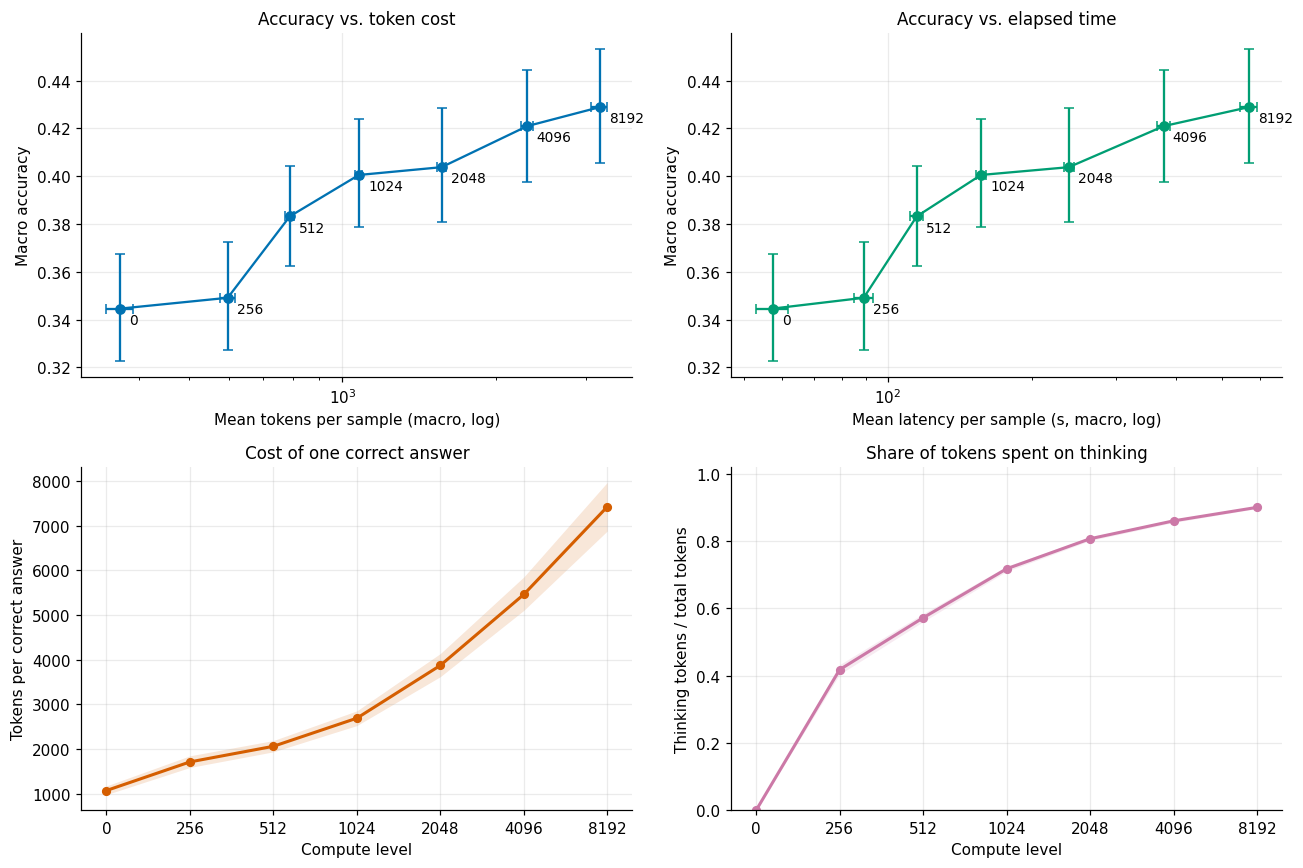

**Observed.** Mean tokens grow 8.7x from `0` to `8192` while macro accuracy changes by +8.4 pp. Tokens per correct answer are lowest at `0` (1,067) and 7,429 at `8192`. The last step costs 886 extra tokens for +0.8 pp accuracy.

**How to read.** Points moving right with little upward movement indicate poor marginal efficiency. **Hypothesis:** the optimal operating point lies where tokens per correct answer is minimal or where the marginal gain per 1,000 tokens falls below a cost threshold the user chooses; this threshold is a business decision, not a statistical one.

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes[0, 0]
if tok is not None:
    ax.errorbar(tok.point, acc.point, yerr=[acc.point - acc.lo, acc.hi - acc.point], xerr=[tok.point - tok.lo, tok.hi - tok.point],
                fmt="o-", color=PALETTE[0], capsize=3, lw=1.5)
    for x, y, lv in zip(tok.point, acc.point, LV):
        ax.annotate(lv, (x, y), textcoords="offset points", xytext=(6, -10), fontsize=9)
    ax.set_xscale("log")
ax.set_xlabel("Mean tokens per sample (macro, log)")
ax.set_ylabel("Macro accuracy")
ax.set_title("Accuracy vs. token cost")

ax = axes[0, 1]
if lat is not None:
    ax.errorbar(lat.point, acc.point, yerr=[acc.point - acc.lo, acc.hi - acc.point], xerr=[lat.point - lat.lo, lat.hi - lat.point],
                fmt="o-", color=PALETTE[2], capsize=3, lw=1.5)
    for x, y, lv in zip(lat.point, acc.point, LV):
        ax.annotate(lv, (x, y), textcoords="offset points", xytext=(6, -10), fontsize=9)
    ax.set_xscale("log")
ax.set_xlabel("Mean latency per sample (s, macro, log)")
ax.set_ylabel("Macro accuracy")
ax.set_title("Accuracy vs. elapsed time")

ax = axes[1, 0]
if tok is not None:
    draw(ax, tpc.point, tpc.lo, tpc.hi, color=PALETTE[3], label="Tokens per correct answer")
    level_axis(ax)
    ax.set_ylabel("Tokens per correct answer")
    ax.set_title("Cost of one correct answer")
ax = axes[1, 1]
if think is not None and tok is not None:
    draw(ax, share_c.point, share_c.lo, share_c.hi, color=PALETTE[4], label="Thinking share")
    level_axis(ax)
    ax.set_ylabel("Thinking tokens / total tokens")
    ax.set_ylim(0, 1.02)
    ax.set_title("Share of tokens spent on thinking")
finish(fig, "09_efficiency")

if tok is not None:
    best = int(np.nanargmin(tpc.point))
    md(f"**Observed.** Mean tokens grow {tok.point[-1] / tok.point[0]:.1f}x from `{LV[0]}` to `{LV[-1]}` while macro accuracy changes by {pp(acc.point[-1] - acc.point[0])}. "
       f"Tokens per correct answer are lowest at `{LV[best]}` ({tpc.point[best]:,.0f}) and {tpc.point[-1]:,.0f} at `{LV[-1]}`. "
       + (f"The last step costs {mr_tbl.d_tokens.iloc[-1]:,.0f} extra tokens for {pp(mr_tbl.d_acc.iloc[-1])} accuracy.\n\n" if len(mr_tbl) else "\n\n")
       + "**How to read.** Points moving right with little upward movement indicate poor marginal efficiency. "
       "**Hypothesis:** the optimal operating point lies where tokens per correct answer is minimal or where the marginal gain per 1,000 tokens falls below a cost threshold the user chooses; this threshold is a business decision, not a statistical one.")

### 9.1 Are longer reasoning traces a sign of failure?

Wrong answers are often *longer* than right ones, but that is confounded by difficulty (hard questions are both longer and more often wrong). To control for it, we compare correct and incorrect samples **of the same question at the same compute level** (only questions with both outcomes), as the log-ratio of mean thinking tokens, macro-averaged over benchmarks. This needs repeated samples.

,correct_vs_incorrect_length_%,ci_low_%,ci_high_%,informative_questions,benchmarks
0,NaN,NaN,NaN,0,0
256,-0.793,-1.648,0.020,281,9
512,-0.599,-2.933,1.742,297,9
1024,-1.251,-4.007,1.612,282,9
2048,-3.323,-7.189,0.394,252,9
4096,-1.567,-7.262,4.865,244,9
8192,-7.405,-14.191,-0.231,251,9


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\09_within_question_length.png


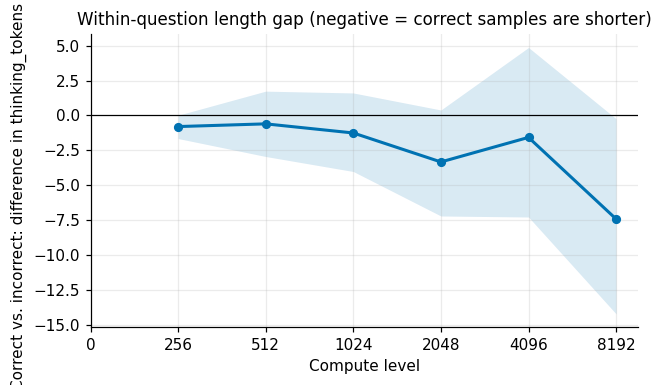

**Observed.** On average across levels, correct samples use 2% fewer thinking_tokens than incorrect samples of the *same* question. **Hypothesis:** if correct samples are consistently shorter, long traces signal confusion or looping (an early-stopping signal could be useful); if they are longer, extra thinking tracks success on that question. This is an association within question and does not show that lengthening or shortening a trace would change the outcome.

In [111]:
tcol = "thinking_tokens" if d["thinking_tokens"].notna().any() else ("tokens_used" if d["tokens_used"].notna().any() else None)
within = None
if tcol is not None:
    g = (d[d[tcol] > 0].groupby(["benchmark", "question_id", "compute_level", "correct"])[tcol].mean().unstack("correct"))
    if 0.0 in g.columns and 1.0 in g.columns:
        both = g.dropna(subset=[0.0, 1.0]).reset_index()
        both["log_ratio"] = np.log(both[1.0] / both[0.0])
        if len(both) >= 20:
            est_w = estimate(both[["benchmark", "question_id", "compute_level", "log_ratio"]], ["log_ratio"], ["benchmark"], balanced=False)
            within = macro(est_w, "log_ratio", full_only=False)
            n_inf = both.groupby("compute_level").size().reindex(LEVELS).fillna(0).astype(int)
if within is None:
    print("Not enough questions with both correct and incorrect samples for a within-question comparison "
          "(needs repeated samples with mixed outcomes).")
else:
    w_tbl = pd.DataFrame({"correct_vs_incorrect_length_%": 100 * (np.exp(within.point) - 1),
                          "ci_low_%": 100 * (np.exp(within.lo) - 1), "ci_high_%": 100 * (np.exp(within.hi) - 1),
                          "informative_questions": n_inf.values, "benchmarks": within.n_cells}, index=LV)
    display(w_tbl)
    fig, ax = plt.subplots(figsize=(6, 3.6))
    draw(ax, 100 * (np.exp(within.point) - 1), 100 * (np.exp(within.lo) - 1), 100 * (np.exp(within.hi) - 1), color=PALETTE[0])
    ax.axhline(0, color="black", lw=0.8)
    level_axis(ax)
    ax.set_ylabel(f"Correct vs. incorrect: difference in {tcol} (%)")
    ax.set_title("Within-question length gap (negative = correct samples are shorter)")
    finish(fig, "09_within_question_length")
    mean_gap = np.nanmean(w_tbl.iloc[:, 0])
    md(f"**Observed.** On average across levels, correct samples use {abs(mean_gap):.0f}% {'fewer' if mean_gap < 0 else 'more'} {tcol} than incorrect samples of the *same* question. "
       "**Hypothesis:** if correct samples are consistently shorter, long traces signal confusion or looping (an early-stopping signal could be useful); if they are longer, extra thinking tracks success on that question. "
       "This is an association within question and does not show that lengthening or shortening a trace would change the outcome.")

## 10. Repeated samples: consistency and pass@k

Multiple samples per question reveal *how* accuracy changes with compute:

* **Consistency:** the share of questions that are always right, always wrong, or mixed. Gains can come from converting "always wrong" questions into "sometimes right", or from making "mixed" questions reliable.
* **pass@k:** the probability that at least one of *k* samples is correct (unbiased estimator from `n` samples with `c` correct: `1 - C(n-c, k) / C(n, k)`). It is an **oracle** metric (it assumes a perfect verifier), so it is an upper bound for any practical selection scheme such as majority voting.
* **Equal-token view:** pass@k at low compute costs about *k* times the tokens of one sample. Plotting pass@k against total tokens compares "think longer" with "sample more" at similar cost.

In [112]:
qcell = (d.groupby(["benchmark", "question_id", "compute_level"])["correct"].agg(acc_q="mean", n_s="count").reset_index())
max_n = int(qcell.n_s.max())
if (qcell.n_s >= 2).mean() < 0.5:
    print("Fewer than half of the question-level cells have >= 2 samples: consistency and pass@k analyses are skipped.")
    HAS_MULTI = False
else:
    HAS_MULTI = True
    print(f"Samples per question-level cell: min {qcell.n_s.min()}, median {qcell.n_s.median():.0f}, max {max_n}.")

    # ---- consistency ----
    cs = qcell[qcell.n_s >= 2].copy()
    cs["all_correct"] = (cs.acc_q == 1).astype(float)
    cs["all_wrong"] = (cs.acc_q == 0).astype(float)
    cs["mixed"] = 1.0 - cs.all_correct - cs.all_wrong
    est_cs = estimate(cs, ["all_correct", "mixed", "all_wrong"], ["benchmark"], balanced=True)
    cons = {k: macro(est_cs, k, full_only=False) for k in ["all_correct", "mixed", "all_wrong"]}
    cons_tbl = pd.DataFrame({k: v.point for k, v in cons.items()}, index=LV)
    display(cons_tbl)

Samples per question-level cell: min 5, median 5, max 5.


,all_correct,mixed,all_wrong
0,0.193,0.325,0.481
256,0.193,0.317,0.489
512,0.226,0.333,0.442
1024,0.246,0.321,0.433
2048,0.268,0.285,0.447
4096,0.283,0.287,0.430
8192,0.289,0.289,0.421


In [113]:
if HAS_MULTI:
    # ---- pass@k ----
    n_mode = int(qcell.n_s.mode().iloc[0])
    K = min(8, n_mode)
    ks = sorted({k for k in (1, 2, 4, 8) if k <= K} | {K})
    sub = qcell[qcell.n_s >= K].copy()
    print(f"pass@k uses question-level cells with >= {K} samples: {len(sub):,} of {len(qcell):,} cells "
          f"({len(qcell) - len(sub):,} excluded for having fewer samples). k evaluated: {ks}")
    c_ok = (sub.acc_q * sub.n_s).round().astype(int).values
    n_s = sub.n_s.values
    for k in ks:
        sub[f"pass@{k}"] = [1 - math.comb(n - c, k) / math.comb(n, k) for n, c in zip(n_s, c_ok)]
    est_pk = estimate(sub, [f"pass@{k}" for k in ks], ["benchmark"], balanced=True)
    pk = {k: macro(est_pk, f"pass@{k}") for k in ks} if est_pk is not None else {}
    if pk:
        pk_tbl = pd.DataFrame({f"pass@{k}": pk[k].point for k in ks}, index=LV)
        display(pk_tbl)

pass@k uses question-level cells with >= 5 samples: 5,810 of 5,810 cells (0 excluded for having fewer samples). k evaluated: [1, 2, 4, 5]


,pass@1,pass@2,pass@4,pass@5
0,0.345,0.423,0.495,0.519
256,0.349,0.428,0.494,0.511
512,0.383,0.464,0.537,0.558
1024,0.401,0.478,0.546,0.567
2048,0.404,0.473,0.536,0.553
4096,0.421,0.491,0.553,0.570
8192,0.429,0.499,0.560,0.579


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\10_repeated_samples.png


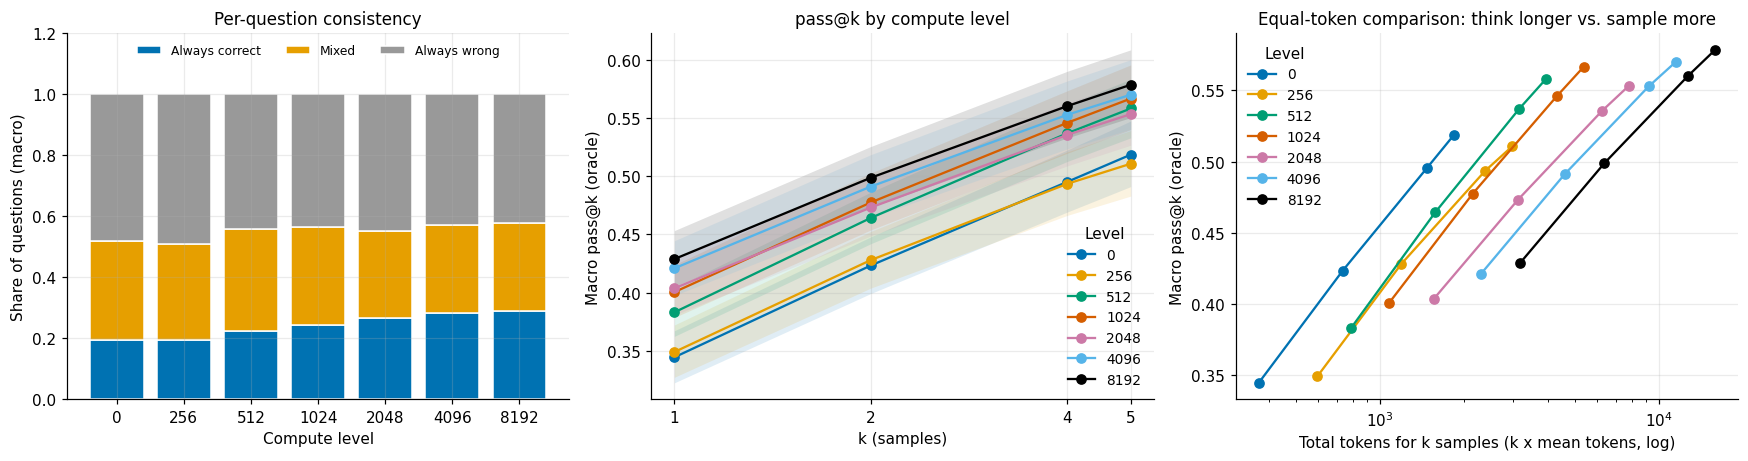

**Observed.** Macro pass@1 changes by +8.4 pp between `0` and `8192`, whereas pass@5 changes by +6.0 pp. The share of *always wrong* questions goes from 48.1% to 42.1%; *mixed* questions from 32.5% to 28.9%.

**How to read.** If pass@k at low compute already reaches the high-compute pass@1, sampling can substitute for deeper reasoning *when a verifier exists*. A large pass@k at equal tokens in the right-hand panel favours sampling; the reverse favours deeper thinking. These are descriptive comparisons: samples are assumed independent given the question, and token cost is approximated as k x the mean per-sample tokens.

In [114]:
if HAS_MULTI and pk:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
    ax = axes[0]
    bottom = np.zeros(L)
    for name, color, label in [("all_correct", PALETTE[0], "Always correct"), ("mixed", PALETTE[1], "Mixed"), ("all_wrong", "#999999", "Always wrong")]:
        v = cons[name].point
        ax.bar(X, v, bottom=bottom, color=color, label=label, edgecolor="white")
        bottom += v
    level_axis(ax)
    ax.set_ylabel("Share of questions (macro)")
    ax.set_title("Per-question consistency")
    ax.set_ylim(0, 1.2)
    ax.legend(loc="upper center", ncol=3, fontsize=8)

    ax = axes[1]
    for li, lv in enumerate(LV):
        pts = np.array([pk[k].point[li] for k in ks])
        lo_ = np.array([pk[k].lo[li] for k in ks])
        hi_ = np.array([pk[k].hi[li] for k in ks])
        ax.plot(ks, pts, marker="o", color=PALETTE[li % len(PALETTE)], label=lv)
        ax.fill_between(ks, lo_, hi_, color=PALETTE[li % len(PALETTE)], alpha=0.12, lw=0)
    ax.set_xscale("log", base=2)
    ax.set_xticks(ks)
    ax.set_xticklabels(ks)
    ax.set_xlabel("k (samples)")
    ax.set_ylabel("Macro pass@k (oracle)")
    ax.set_title("pass@k by compute level")
    ax.legend(title="Level")

    ax = axes[2]
    if tok is not None:
        for li, lv in enumerate(LV):
            xs = np.array([k * tok.point[li] for k in ks])
            ys = np.array([pk[k].point[li] for k in ks])
            ax.plot(xs, ys, marker="o", color=PALETTE[li % len(PALETTE)], label=lv)
        ax.set_xscale("log")
        ax.set_xlabel("Total tokens for k samples (k x mean tokens, log)")
        ax.set_ylabel("Macro pass@k (oracle)")
        ax.set_title("Equal-token comparison: think longer vs. sample more")
        ax.legend(title="Level")
    else:
        ax.axis("off")
    finish(fig, "10_repeated_samples")

    gap1 = pk[1].point[-1] - pk[1].point[0]
    gapK = pk[ks[-1]].point[-1] - pk[ks[-1]].point[0]
    md(f"**Observed.** Macro pass@1 changes by {pp(gap1)} between `{LV[0]}` and `{LV[-1]}`, whereas pass@{ks[-1]} changes by {pp(gapK)}. "
       f"The share of *always wrong* questions goes from {pct(cons['all_wrong'].point[0])} to {pct(cons['all_wrong'].point[-1])}; "
       f"*mixed* questions from {pct(cons['mixed'].point[0])} to {pct(cons['mixed'].point[-1])}.\n\n"
       "**How to read.** If pass@k at low compute already reaches the high-compute pass@1, sampling can substitute for deeper reasoning *when a verifier exists*. "
       "A large pass@k at equal tokens in the right-hand panel favours sampling; the reverse favours deeper thinking. These are descriptive comparisons: samples are assumed independent given the question, and token cost is approximated as k x the mean per-sample tokens.")

## 11. Truncation and response-format issues

A sample can fail because the model *ran out of budget*, *never emitted the response marker*, or *emitted the marker but no answer*. These failures are mechanical rather than a matter of reasoning quality, and they can differ by compute level. Interpretation of the flags assumed here (adjust if your pipeline defines them differently):

* `was_truncated` — generation stopped at the token limit;
* `hit_response_marker` — the model emitted the delimiter separating thinking from the final answer;
* `hit_marker_empty_output` — the marker was emitted but the answer section is empty.

Each row is assigned to **one** mutually exclusive outcome (priority: truncated > marker-but-empty > no marker > complete). All rows remain in the accuracy calculations as graded — nothing is dropped; the "excluding truncated" curve below is a *sensitivity analysis*, not a replacement.

In [115]:
flag_cols = ["was_truncated", "hit_response_marker", "hit_marker_empty_output"]
HAS_FLAGS = d[flag_cols].notna().any().any()
if not HAS_FLAGS:
    print("No truncation/format flags available; this section is skipped.")
else:
    tr, mk, me = d["was_truncated"], d["hit_response_marker"], d["hit_marker_empty_output"]
    cat = np.select([tr == 1, me == 1, mk == 0],
                    ["Truncated", "Marker hit, empty answer", "No marker (not truncated)"], default="Complete")
    d["outcome"] = np.where(tr.isna() & mk.isna() & me.isna(), "Unknown", cat)
    outcome_names = [o for o in ["Complete", "Truncated", "Marker hit, empty answer", "No marker (not truncated)", "Unknown"] if (d.outcome == o).any()]
    for o in outcome_names:
        d[f"is_{o}"] = (d.outcome == o).astype(float)
    est_out = estimate(d, [f"is_{o}" for o in outcome_names], ["benchmark"], balanced=True)
    out_curves = {o: macro(est_out, f"is_{o}") for o in outcome_names}
    out_tbl = pd.DataFrame({o: c.point for o, c in out_curves.items()}, index=LV)
    print("Macro share of rows per outcome (equal benchmark weight, same questions at every level):")
    display(out_tbl)

    acc_by = d.groupby(["compute_level", "outcome"])["correct"].agg(["mean", "count"]).unstack("outcome")
    acc_by = acc_by.reindex(LEVELS)
    print("Row-pooled accuracy by outcome (and number of rows):")
    display(acc_by["mean"].set_axis(LV, axis=0))
    display(acc_by["count"].fillna(0).astype(int).set_axis(LV, axis=0))

Macro share of rows per outcome (equal benchmark weight, same questions at every level):


,Complete
0,1.000
256,1.000
512,1.000
1024,1.000
2048,1.000
4096,1.000
8192,1.000


Row-pooled accuracy by outcome (and number of rows):


outcome,Complete
0,0.373
256,0.377
512,0.415
1024,0.430
2048,0.433
4096,0.447
8192,0.457


outcome,Complete
0,4150
256,4150
512,4150
1024,4150
2048,4150
4096,4150
8192,4150


C:\Users\afath\AppData\Local\Temp\ipykernel_1012\904964528.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


Saved figure: ..\..\results\r1-llama8b_raw_results\compute_level_analysis\Figures\11_truncation.png


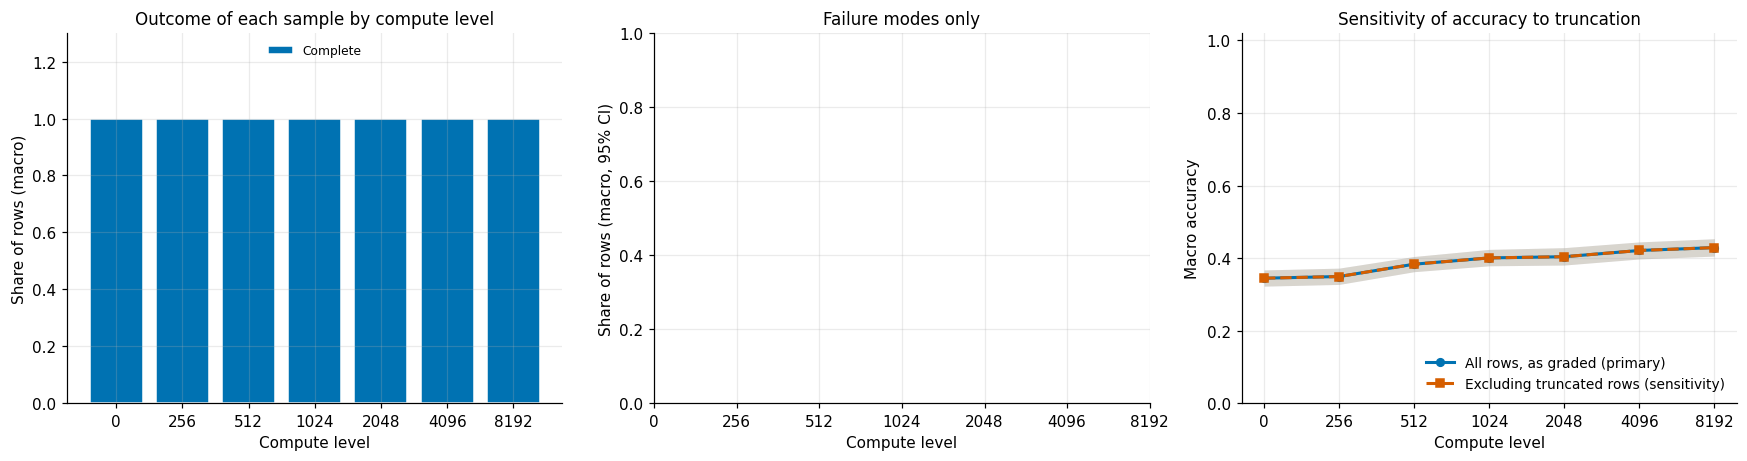

**Observed.** Excluding truncated rows, macro accuracy changes by +8.4 pp between the extreme levels (vs. +8.4 pp with all rows).

**How to read.** The truncation-excluded curve is **selection-biased**: truncated samples are usually the hardest questions, so excluding them flatters accuracy, and the set of surviving questions changes by level. It indicates how much of the observed shortfall is mechanical (budget exhaustion) rather than a reasoning failure. **Hypothesis:** a decline in accuracy at high compute together with a rising truncated share suggests a fixed output cap is limiting the highest levels; a rising 'empty answer' share suggests the model spends its budget thinking and never answers.

In [116]:
if HAS_FLAGS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
    ax = axes[0]
    bottom = np.zeros(L)
    colors = {"Complete": PALETTE[0], "Truncated": PALETTE[3], "Marker hit, empty answer": PALETTE[1],
              "No marker (not truncated)": PALETTE[4], "Unknown": "#999999"}
    for o in outcome_names:
        v = np.nan_to_num(out_curves[o].point)
        ax.bar(X, v, bottom=bottom, color=colors[o], label=o, edgecolor="white")
        bottom += v
    level_axis(ax)
    ax.set_ylabel("Share of rows (macro)")
    ax.set_title("Outcome of each sample by compute level")
    ax.set_ylim(0, 1.3)
    ax.legend(fontsize=8, loc="upper center", ncol=2)

    ax = axes[1]
    for o in outcome_names:
        if o != "Complete":
            c = out_curves[o]
            draw(ax, c.point, c.lo, c.hi, color=colors[o], label=o)
    level_axis(ax)
    ax.set_ylabel("Share of rows (macro, 95% CI)")
    ax.set_title("Failure modes only")
    ax.legend(fontsize=8)

    # Sensitivity: accuracy if truncated rows were excluded (selection-biased!)
    ax = axes[2]
    draw(ax, m_primary.point, m_primary.lo, m_primary.hi, color=PALETTE[0], label="All rows, as graded (primary)")
    nt = d[d.was_truncated != 1]
    est_nt = estimate(nt, ["correct"], ["benchmark"], balanced=False)
    m_nt = macro(est_nt, "correct", full_only=True) if est_nt is not None else None
    if m_nt is not None:
        draw(ax, m_nt.point, m_nt.lo, m_nt.hi, color=PALETTE[3], ls="--", marker="s", label="Excluding truncated rows (sensitivity)")
    level_axis(ax)
    ax.set_ylabel("Macro accuracy")
    ax.set_ylim(0, 1.02)
    ax.set_title("Sensitivity of accuracy to truncation")
    ax.legend(loc="lower right")
    finish(fig, "11_truncation")

    t = out_curves.get("Truncated")
    parts = []
    if t is not None:
        parts.append(f"Truncated share: {pct(t.point[0])} at `{LV[0]}` -> {pct(t.point[-1])} at `{LV[-1]}`.")
    if m_nt is not None:
        parts.append(f"Excluding truncated rows, macro accuracy changes by {pp(m_nt.point[-1] - m_nt.point[0])} between the extreme levels "
                     f"(vs. {pp(m_primary.point[-1] - m_primary.point[0])} with all rows).")
    other = [o for o in outcome_names if o in ("Marker hit, empty answer", "No marker (not truncated)")]
    for o in other:
        parts.append(f"'{o}': {pct(out_curves[o].point[0])} -> {pct(out_curves[o].point[-1])}.")
    md("**Observed.** " + " ".join(parts) + "\n\n"
       "**How to read.** The truncation-excluded curve is **selection-biased**: truncated samples are usually the hardest questions, so excluding them flatters accuracy, "
       "and the set of surviving questions changes by level. It indicates how much of the observed shortfall is mechanical (budget exhaustion) rather than a reasoning failure. "
       "**Hypothesis:** a decline in accuracy at high compute together with a rising truncated share suggests a fixed output cap is limiting the highest levels; a rising 'empty answer' share suggests the model spends its budget thinking and never answers.")

## 12. Synthesis

The summary below is **generated from the results above** (all numbers update with the data). It states observed quantities with their uncertainty and keeps hypotheses separate. Read it together with the limitations that follow.

In [117]:
lines = []
a0, a1 = m_primary.point[0], m_primary.point[-1]
dm, dm_lo, dm_hi = m_primary.diff(0, -1)
best_i = int(np.argmax(m_primary.point))
n_bm = len(m_primary.cells)
n_q_primary = int(sum(PRIMARY.nq[PRIMARY.cells.index(c)] for c in m_primary.cells))

lines.append(f"**Data and design.** {len(d):,} graded samples, {d.groupby(['benchmark', 'question_id']).ngroups:,} questions, {d.benchmark.nunique()} benchmarks, "
             f"{L} compute levels ({' < '.join(LV)}). The primary estimate uses {n_bm} benchmark(s) and {n_q_primary:,} questions observed at every level.")
lines.append(f"**Overall accuracy (macro, same questions).** {pct(a0)} at `{LV[0]}` -> {pct(a1)} at `{LV[-1]}`: change {pp(dm)} "
             f"[{int(CI_LEVEL * 100)}% CI {pp(dm_lo)}, {pp(dm_hi)}] — *{sig(dm_lo, dm_hi)}*. Highest point estimate at `{LV[best_i]}`.")
dp_ = pooled["accuracy"].iloc[-1] - pooled["accuracy"].iloc[0]
lines.append(f"**Pooled vs. normalised.** Pooled change is {pp(dp_)} vs. {pp(dm)} for the primary estimate "
             + ("— **opposite directions (Simpson-type effect): the pooled curve should not be used.**" if simpson_flag
                else f"(gap {pp(dp_ - dm)}); no sign reversal.")
             + (f" Benchmark coverage is incomplete for: {partial_bench}." if partial_bench else " All benchmarks are observed at every level."))
v = bench_delta["verdict"].value_counts()
lines.append(f"**Per benchmark.** Credible increase: {v.get('increase', 0)}, no clear change: {v.get('no clear change', 0)}, credible decrease: {v.get('decrease', 0)} "
             f"(of {int(v.drop('n/a (no common questions)', errors='ignore').sum())} assessable benchmarks; extreme levels, identical questions)."
             + (f" {len(bench_delta) - int(v.drop('n/a (no common questions)', errors='ignore').sum())} benchmark(s) had no questions common to all levels." if len(bench_delta) > v.drop('n/a (no common questions)', errors='ignore').sum() else ""))
if tt_curves:
    lines.append("**Task types.** " + "; ".join(f"{t}: {pp(r.delta_macro)} [{pp(r.ci_low)}, {pp(r.ci_high)}] ({int(r.benchmarks)} bm)" for t, r in tt_tbl.iterrows()) + ".")
lines.append("**Step-wise gains (diminishing returns).** " + ", ".join(f"{i}: {pp(r.gain)} [{pp(r.ci_low)}, {pp(r.ci_high)}]" for i, r in step_tbl.iterrows()) + ".")
if dt_curves:
    lines.append("**Difficulty.** " + "; ".join(f"{t}: {pp(r.delta)}" for t, r in dt_tbl.iterrows()) + ".")
if lat is not None:
    lines.append(f"**Latency.** Macro mean latency grows {lat_ratio.point[-1]:.1f}x (CI {lat_ratio.lo[-1]:.1f}-{lat_ratio.hi[-1]:.1f}x) from `{LV[0]}` to `{LV[-1]}`.")
if tok is not None:
    lines.append(f"**Efficiency.** Mean tokens grow {tok.point[-1] / tok.point[0]:.1f}x; tokens per correct answer: {tpc.point[0]:,.0f} -> {tpc.point[-1]:,.0f} "
                 f"(minimum at `{LV[int(np.nanargmin(tpc.point))]}`).")
if HAS_MULTI and pk:
    lines.append(f"**Repeated samples.** pass@1 change {pp(pk[1].point[-1] - pk[1].point[0])}; pass@{ks[-1]} change {pp(pk[ks[-1]].point[-1] - pk[ks[-1]].point[0])}.")
if HAS_FLAGS and out_curves.get("Truncated") is not None:
    t = out_curves["Truncated"]
    lines.append(f"**Truncation.** Truncated share {pct(t.point[0])} -> {pct(t.point[-1])}.")
md("\n\n".join(f"- {x}" for x in lines))

- **Data and design.** 29,050 graded samples, 830 questions, 9 benchmarks, 7 compute levels (0 < 256 < 512 < 1024 < 2048 < 4096 < 8192). The primary estimate uses 9 benchmark(s) and 830 questions observed at every level.

- **Overall accuracy (macro, same questions).** 34.5% at `0` -> 42.9% at `8192`: change +8.4 pp [95% CI +6.5 pp, +10.6 pp] — *increase*. Highest point estimate at `8192`.

- **Pooled vs. normalised.** Pooled change is +8.4 pp vs. +8.4 pp for the primary estimate (gap -0.0 pp); no sign reversal. All benchmarks are observed at every level.

- **Per benchmark.** Credible increase: 6, no clear change: 2, credible decrease: 1 (of 9 assessable benchmarks; extreme levels, identical questions).

- **Task types.** MCQ: +9.3 pp [+5.9 pp, +12.9 pp] (3 bm); Open-ended: +8.0 pp [+5.5 pp, +10.5 pp] (6 bm).

- **Step-wise gains (diminishing returns).** 0 -> 256: +0.5 pp [-1.1 pp, +2.1 pp], 256 -> 512: +3.4 pp [+2.1 pp, +4.8 pp], 512 -> 1024: +1.7 pp [+0.4 pp, +3.2 pp], 1024 -> 2048: +0.3 pp [-1.0 pp, +1.6 pp], 2048 -> 4096: +1.7 pp [+0.3 pp, +3.1 pp], 4096 -> 8192: +0.8 pp [-0.4 pp, +1.9 pp].

- **Difficulty.** easy: +10.7 pp; medium: +10.7 pp; hard: +3.9 pp.

- **Latency.** Macro mean latency grows 9.9x (CI 9.3-10.7x) from `0` to `8192`.

- **Efficiency.** Mean tokens grow 8.7x; tokens per correct answer: 1,067 -> 7,429 (minimum at `0`).

- **Repeated samples.** pass@1 change +8.4 pp; pass@5 change +6.0 pp.

### Limitations and how to read the evidence

* **Observational comparison.** Unless compute level was randomly assigned to identical questions, differences may reflect unrecorded differences between runs (hardware, date, prompt version, sampling settings). The same-question design removes *question* confounding, not run-level confounding.
* **Benchmarks are a fixed, non-random set.** Intervals reflect question sampling within benchmarks. Equal-weight macro-averaging is a *choice* (it answers "how does an average benchmark behave?"); a different weighting (e.g. by deployment relevance) would answer a different question. Leave-one-out results (Section 5) show how sensitive the aggregate is to this choice.
* **Primary estimate excludes incomplete coverage.** Benchmarks or questions missing at some levels are reported but not used for level-to-level comparison; if they differ systematically from the retained ones, the primary curve may not generalise to them.
* **Task-type and difficulty comparisons are descriptive.** Types with few benchmarks cannot be separated from benchmark idiosyncrasies; tier definitions may not be comparable across benchmarks. No multiplicity correction is applied to the many intervals shown, so isolated "credible" results should be treated as leads, not confirmations.
* **Ordering of levels.** Levels are treated as ordered categories; if the spacing in real compute is unequal, step-wise "diminishing returns" is partly an artefact of spacing (Section 9 reports per-token and per-second returns).
* **Latency.** Depends on hardware, batching and load which are not in the data. Token counts and latency may also be affected by truncation limits.
* **pass@k** assumes a perfect verifier and independent samples; the equal-token comparison is an approximation.
* **Interpretation of flags** (`was_truncated`, `hit_response_marker`, `hit_marker_empty_output`) follows the definitions stated in Section 11.
* **Grading noise.** Unreadable `is_correct` labels were handled according to `MISSING_CORRECT`; label errors in the benchmark itself are not assessed.

**Suggested follow-ups** (only if the findings above warrant them): re-run the primary analysis with a higher output-token cap if truncation is material at the top levels; add benchmarks or questions at levels with thin coverage; test a cheap early-stopping or adaptive-compute rule if long traces were associated with failure (Section 9.1).